In [318]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# Carrega o dataset de breast-cancer-dataset.csv
df = pd.read_csv('datasets/breast-cancer-dataset.csv')

In [319]:
# Mostra as primeiras 5 linhas e informações gerais
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [320]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Observações importantes sobre o conjuntos de dados:

Total de colunas: 33 colunas

Informações dos atributos:

Número de identificação (ID)
Diagnóstico (M = maligno, B = benigno)

Dez características de valor real são calculadas para cada núcleo celular:

a - raio (média das distâncias do centro até os pontos do perímetro)

b - textura (desvio padrão dos valores em escala de cinza)

c - perímetro

d - área

e - suavidade (variação local dos comprimentos do raio)

f - compacidade (perímetro² / área − 1,0)

g - concavidade (gravidade das porções côncavas do contorno)

h - pontos côncavos (número de porções côncavas do contorno)

i - simetria

j - dimensão fractal (“aproximação da linha costeira” − 1)


A média, o erro padrão e o “pior” ou maior valor (média dos três maiores valores) dessas características foram calculados para cada imagem, resultando em 30 características. Por exemplo, o campo 3 corresponde ao Raio Médio, o campo 13 ao Erro Padrão do Raio, e o campo 23 ao Pior Raio.

Todos os valores das características foram recodificados com quatro algarismos significativos.
Valores de atributos ausentes: nenhum.
Distribuição das classes: 357 benignos, 212 malignos.


In [321]:
# Varrendo todas as colunas 
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")
    
# Verifica se a última coluna está vazia
last_col = df.columns[-1]
print(f"\nÚltima coluna: '{last_col}'")
print(f"Valores não-nulos: {df[last_col].notna().sum()} de {len(df)}")
print(f"Valores únicos: {df[last_col].nunique()}")


 1. id
 2. diagnosis
 3. radius_mean
 4. texture_mean
 5. perimeter_mean
 6. area_mean
 7. smoothness_mean
 8. compactness_mean
 9. concavity_mean
10. concave points_mean
11. symmetry_mean
12. fractal_dimension_mean
13. radius_se
14. texture_se
15. perimeter_se
16. area_se
17. smoothness_se
18. compactness_se
19. concavity_se
20. concave points_se
21. symmetry_se
22. fractal_dimension_se
23. radius_worst
24. texture_worst
25. perimeter_worst
26. area_worst
27. smoothness_worst
28. compactness_worst
29. concavity_worst
30. concave points_worst
31. symmetry_worst
32. fractal_dimension_worst
33. Unnamed: 32

Última coluna: 'Unnamed: 32'
Valores não-nulos: 0 de 569
Valores únicos: 0


Existe uma coluna vazia e vamos removê-la, assim como a coluna `id` que é apenas um identificador e não tem valor preditivo.


In [322]:
# Verifica valores ausentes em todas as colunas
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Mostra apenas colunas com valores ausentes
missing_data = pd.DataFrame({
    'Coluna': missing_values.index,
    'Valores Ausentes': missing_values.values,
    'Percentual (%)': missing_percent.values
})
missing_data = missing_data[missing_data['Valores Ausentes'] > 0].sort_values('Valores Ausentes', ascending=False)

if len(missing_data) > 0:
    print("\n Colunas com valores ausentes:")
    print(missing_data.to_string(index=False))
else:
    print("\n Nenhum valor ausente encontrado!")

# Verifica colunas com muitos valores ausentes ou vazias
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0 or df[col].nunique() == 0:
        print(f"\n{col}': {null_count} valores ausentes, {df[col].nunique()} valores únicos")



 Colunas com valores ausentes:
     Coluna  Valores Ausentes  Percentual (%)
Unnamed: 32               569           100.0

Unnamed: 32': 569 valores ausentes, 0 valores únicos


In [323]:
# Remover coluna 'id' e coluna vazia
empty_cols = [col for col in df.columns if df[col].isnull().all()]

if 'id' in df.columns:
    df = df.drop(columns=['id'])

for col in empty_cols:
    df = df.drop(columns=[col])

A variável target será a coluna `diagnosis`, que classifica o tumor como:
- **B** = Benigno (não canceroso)
- **M** = Maligno (canceroso)


Verificaremos se as classes estão balanceadas. 

In [324]:
# Contagem de cada classe
target_counts = df['diagnosis'].value_counts()
target_percent = df['diagnosis'].value_counts(normalize=True) * 100

for classe in target_counts.index:
    count = target_counts[classe]
    percent = target_percent[classe]
    label = "B" if classe == 'B' else "M"
    print(f"{label}: {count:3d} casos ({percent:5.2f}%)")

print(f"\nTotal: {len(df)} casos")

# Balanceamento
ratio = min(target_counts) / max(target_counts)
print(f"\nRazão de balanceamento: {ratio:.2f}")

B: 357 casos (62.74%)
M: 212 casos (37.26%)

Total: 569 casos

Razão de balanceamento: 0.59


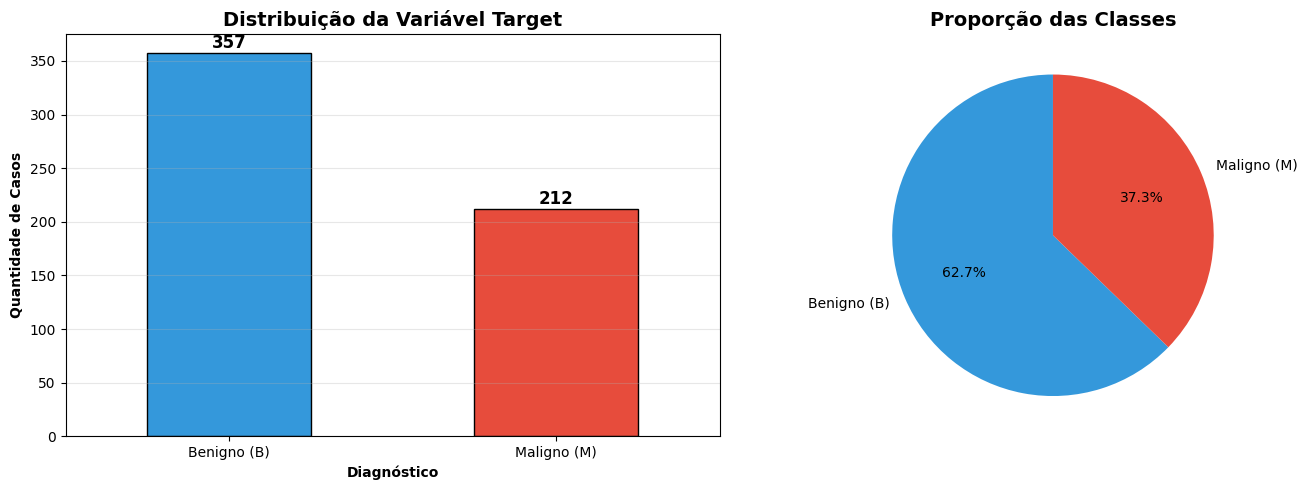

In [325]:
# Visualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
target_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribuição da Variável Target', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Diagnóstico', fontweight='bold')
axes[0].set_ylabel('Quantidade de Casos', fontweight='bold')
axes[0].set_xticklabels(['Benigno (B)', 'Maligno (M)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

# Gráfico de pizza
colors = ['#3498db', '#e74c3c']
labels = ['Benigno (B)', 'Maligno (M)']
target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, 
                   startangle=90, labels=labels)
axes[1].set_title('Proporção das Classes', fontweight='bold', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


Vamos verificar as estatísticas descritivas:
- **Média**: valor central
- **Desvio padrão**: variabilidade dos dados
- **Valores mínimo e máximo**: faixa de valores
- **Quartis (25%, 50%, 75%)**: distribuição dos dados

In [326]:
# Separar apenas colunas numéricas (excluindo diagnosis)
numeric_cols = df.select_dtypes(include=[np.number]).columns
stats = df[numeric_cols].describe()

# Mostrar as estatísticas
stats


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


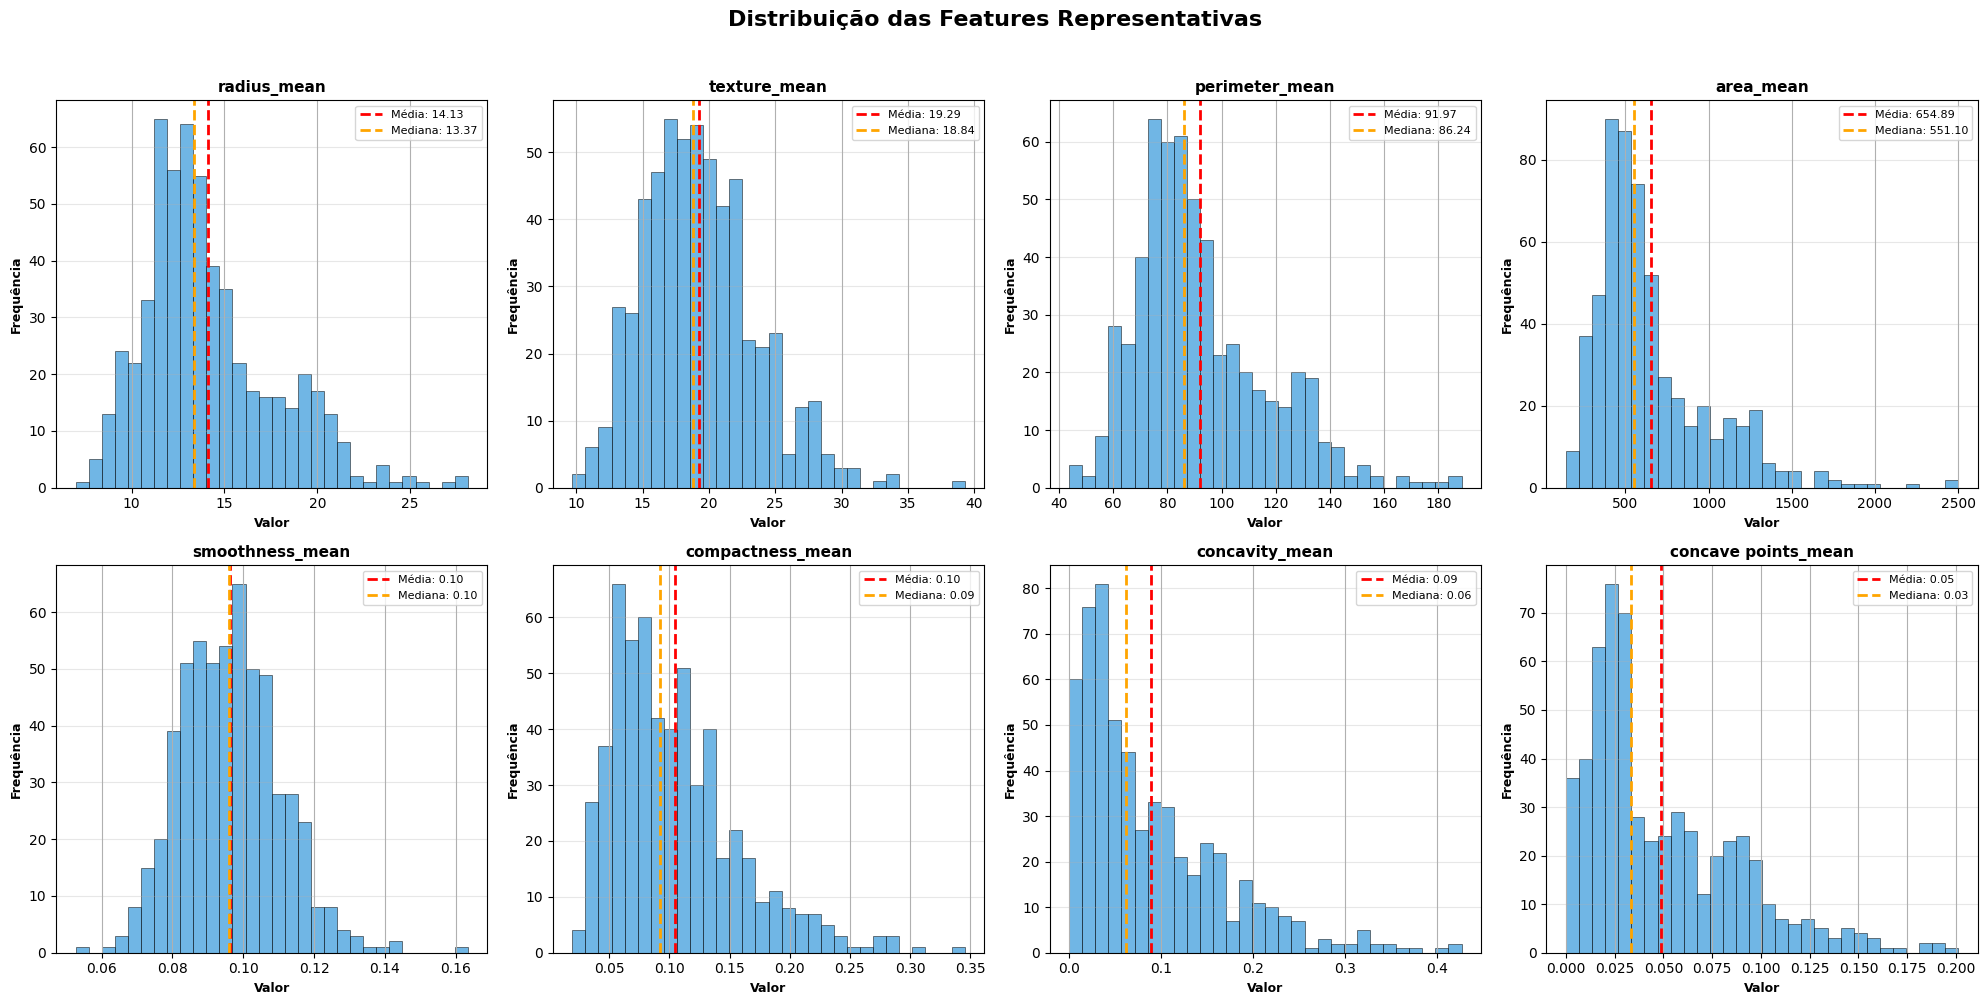

In [327]:
# Visualização da distribuição média dos dados
features_dist = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean']

# Criar histogramas para visualizar a distribuição
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribuição das Features Representativas', fontweight='bold', fontsize=16, y=1.0)

axes = axes.flatten()

#histograma geral
for idx, feature in enumerate(features_dist):
    df[feature].hist(ax=axes[idx], bins=30, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df[feature].mean():.2f}')
    axes[idx].axvline(df[feature].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df[feature].median():.2f}')
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


A correlação mede a relação linear entre duas variáveis. Algumas observaçÕes sobre a correlação:
- Features muito correlacionadas podem ser redundantes
- Correlação alta com a variável target indica features importantes
- Multicolinearidade (correlação alta entre features) pode afetar alguns modelos
- Quanto maior a correlação, mais importante a feature para prever o diagnóstico


In [328]:
# Primeiro, vamos codificar a variável target (B=0, M=1) para incluir na correlação
df_corr = df.copy()
df_corr['diagnosis_encoded'] = df_corr['diagnosis'].map({'B': 0, 'M': 1})

# Calcula a correlação com a variável target
correlation_with_target = df_corr[numeric_cols].corrwith(df_corr['diagnosis_encoded']).abs().sort_values(ascending=False)

# Exibir as 10 features mais correlacionadas
for i, (feature, corr) in enumerate(correlation_with_target.head(10).items(), 1):
    print(f"{i:2d}. {feature:30s}: {corr:.4f}")


 1. concave points_worst          : 0.7936
 2. perimeter_worst               : 0.7829
 3. concave points_mean           : 0.7766
 4. radius_worst                  : 0.7765
 5. perimeter_mean                : 0.7426
 6. area_worst                    : 0.7338
 7. radius_mean                   : 0.7300
 8. area_mean                     : 0.7090
 9. concavity_mean                : 0.6964
10. concavity_worst               : 0.6596


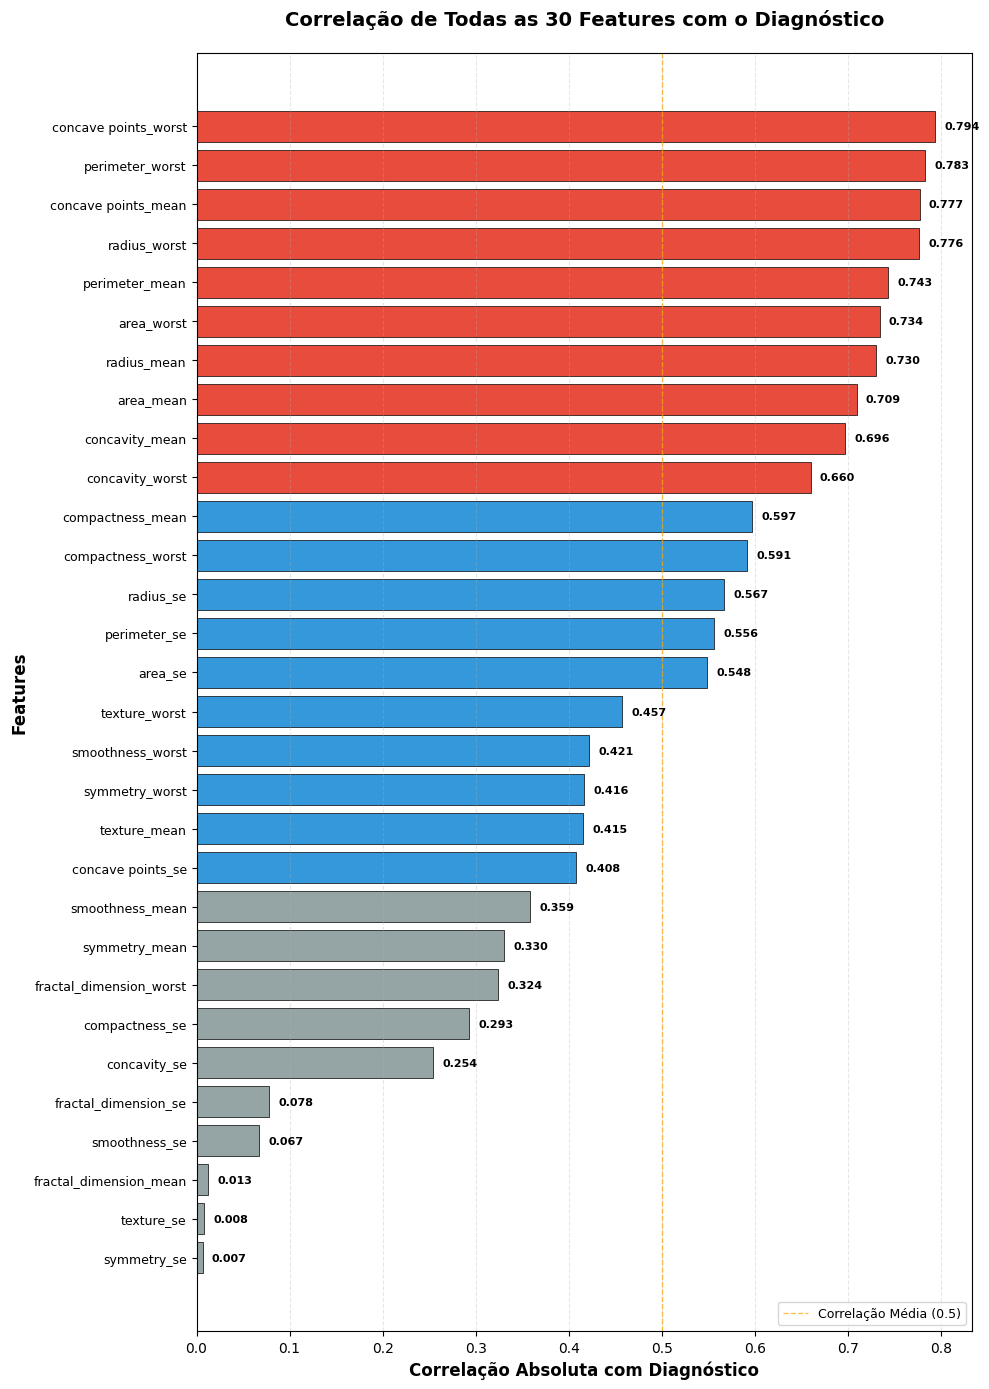

In [329]:
# Gráfico de barras de correlação de todas as 30 features com o target
# Ordenando todas as correlações (absolutas) por valor
correlation_all = df_corr[numeric_cols].corrwith(df_corr['diagnosis_encoded']).abs().sort_values(ascending=True)

# Criar gráfico de barras horizontal
plt.figure(figsize=(10, 14))
colors = ['#e74c3c' if corr > 0.6 else '#3498db' if corr > 0.4 else '#95a5a6' for corr in correlation_all.values]
bars = plt.barh(range(len(correlation_all)), correlation_all.values, color=colors, edgecolor='black', linewidth=0.5)

plt.yticks(range(len(correlation_all)), correlation_all.index, fontsize=9)
plt.xlabel('Correlação Absoluta com Diagnóstico', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)
plt.title('Correlação de Todas as 30 Features com o Diagnóstico', fontweight='bold', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Adicionar valores nas barras
for i, (idx, corr) in enumerate(correlation_all.items()):
    plt.text(corr + 0.01, i, f'{corr:.3f}', va='center', fontsize=8, fontweight='bold')

# Adicionar linha vertical de referência
plt.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Correlação Média (0.5)')
plt.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


A interpretação da matriz de correlação:

- Valores próximos de +1: correlação positiva forte (quando uma aumenta, a outra aumenta)
- Valores próximos de -1: correlação negativa forte (quando uma aumenta, a outra diminui)
- Valores próximos de 0: pouca ou nenhuma correlação

O heatmap de correlação identifica padrões de relacionamento entre variáveis 
- Detecta multicolinearidade, evidenciando variáveis altamente correlacionadas (próximas de +1 ou −1) 
- Auxilia diretamente na seleção de features ao destacar quais atributos possuem maior correlação com o target e quais apresentam correlação forte entre si
- Contribui para a otimização dos modelos ao apoiar a redução de dimensionalidade, minimizar riscos de overfitting e melhorar a performance geral dos algoritmos de classificação.

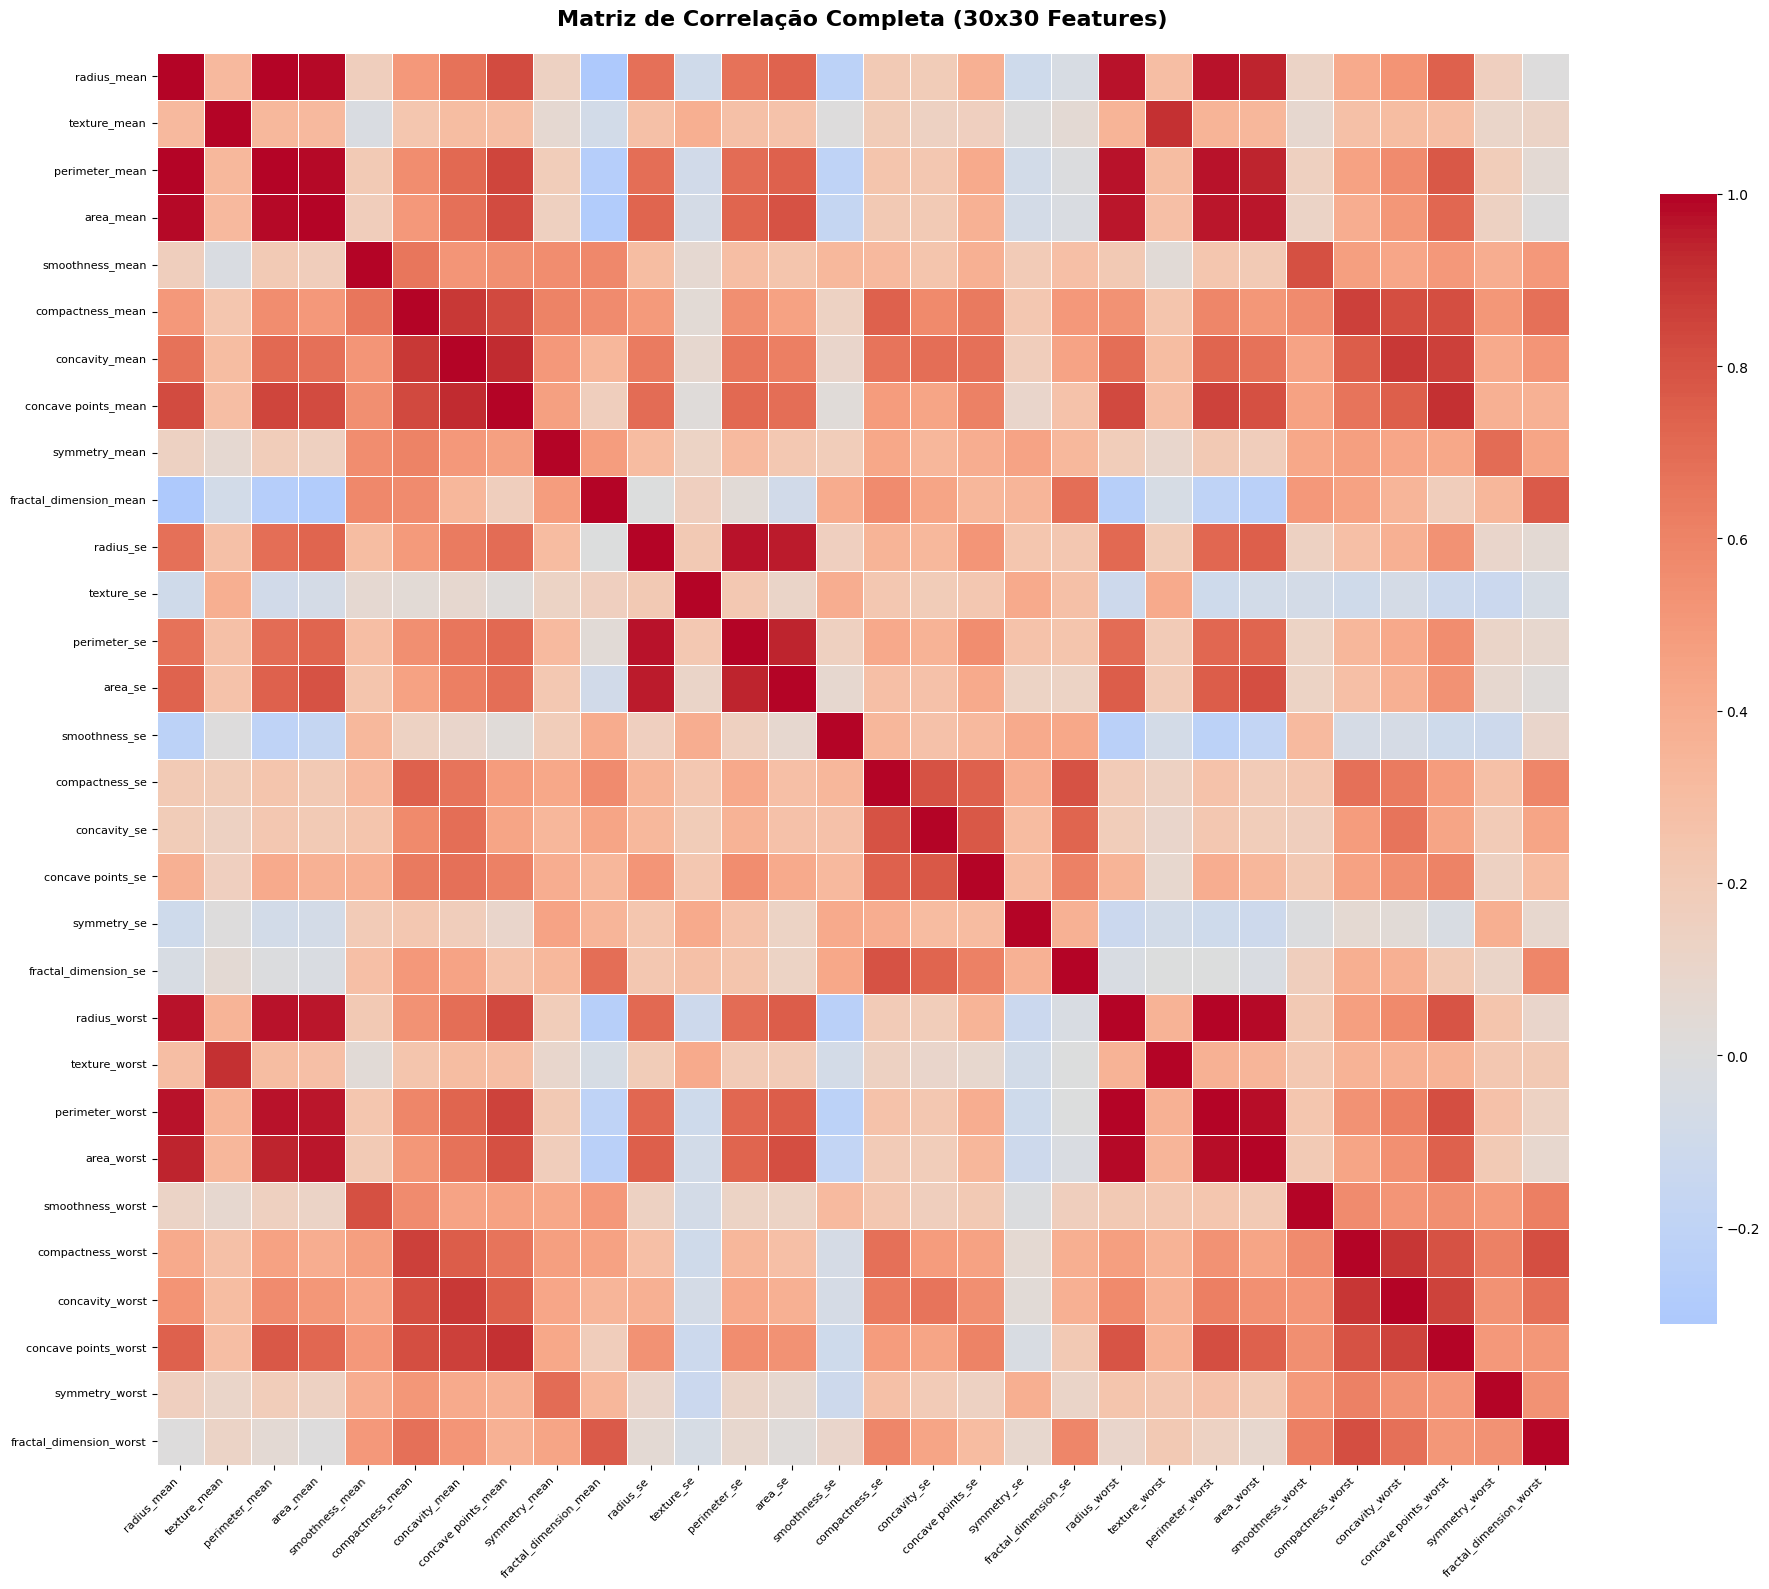

In [330]:
# Heatmap de correlação completa
corr_matrix_all = df_corr[numeric_cols].corr()

# Criar heatmap completo
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_all, annot=False, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, 
            xticklabels=True, yticklabels=True)
plt.title('Matriz de Correlação Completa (30x30 Features)', fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


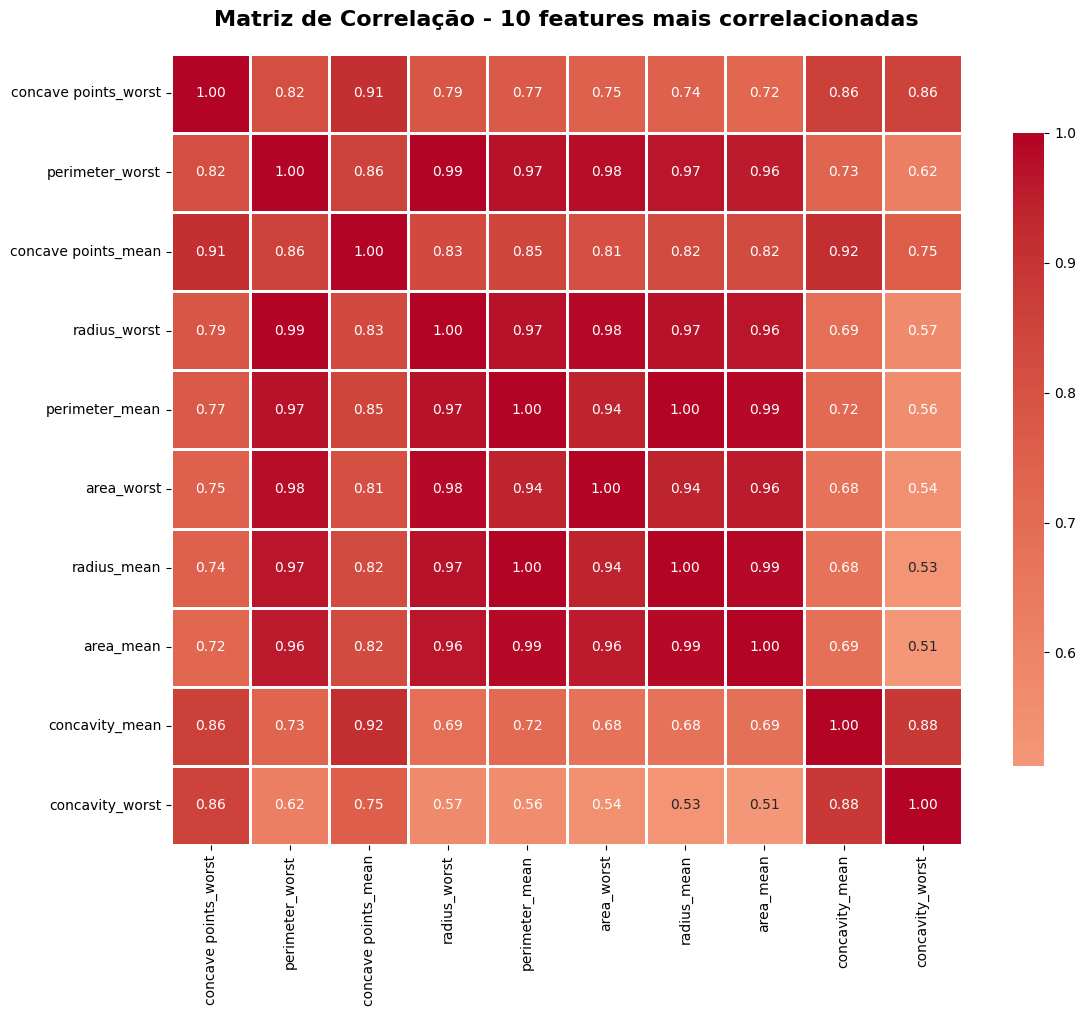

In [331]:
# Seleciona as 10 features mais correlacionadas
top_features = correlation_with_target.head(10).index.tolist()
corr_matrix = df_corr[top_features].corr()

# Criar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - 10 features mais correlacionadas', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


Os gráficos para entender os dados e comparar as features entre as classes Benigno e Maligno.
- Boxplots mostram a distribuição e outliers de cada classe
- Histogramas mostram a forma das distribuições
- Quanto mais separadas as distribuições, melhor a feature para classificação!

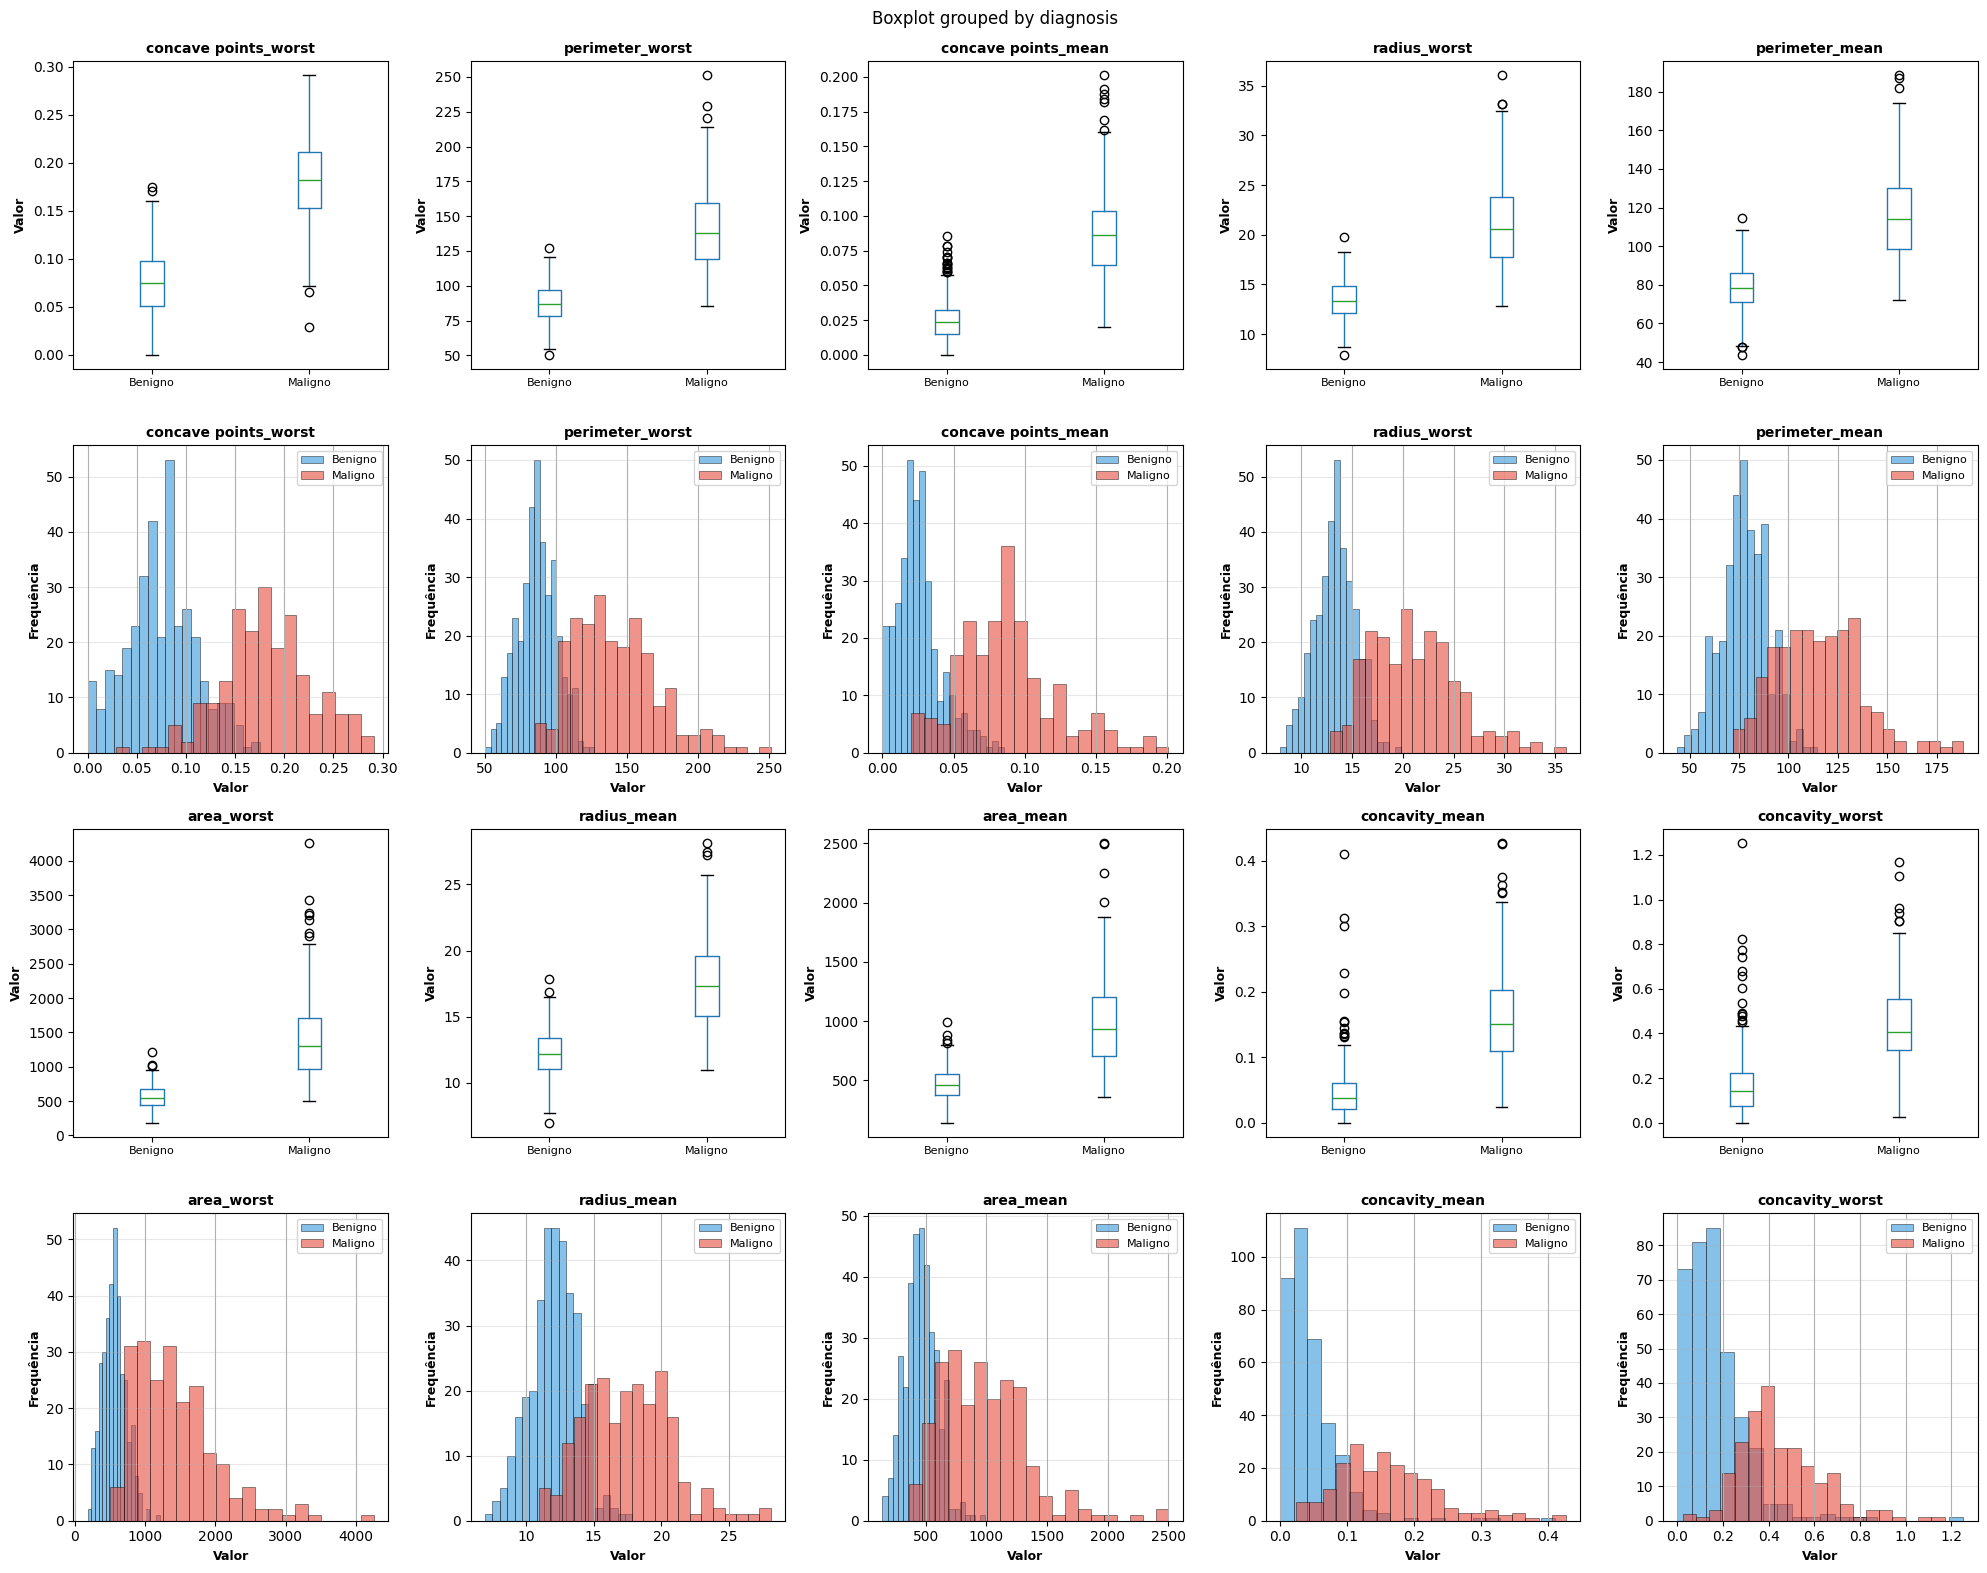

In [332]:
# Seleciona as 10 features para visualização
top_10_features = correlation_with_target.head(10).index.tolist()

# Boxplots e Histogramas
# 4 linhas x 5 colunas = 20 subplots (2 gráficos para cada uma das 10 features)
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Distribuições das 10 Features Mais Correlacionadas por Classe', 
              fontweight='bold', fontsize=18, y=0.995)

# Primeiras 5 features (linhas 0 e 1)
for idx, feature in enumerate(top_10_features[:5]):
    # Boxplot (linha 0)
    df.boxplot(column=feature, by='diagnosis', ax=axes[0, idx], grid=False)
    axes[0, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[0, idx].set_xlabel('')
    axes[0, idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[0, idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=8)
    
    # Histograma (linha 1)
    df[df['diagnosis'] == 'B'][feature].hist(ax=axes[1, idx], alpha=0.6, label='Benigno', 
                                              color='#3498db', bins=20, edgecolor='black', linewidth=0.5)
    df[df['diagnosis'] == 'M'][feature].hist(ax=axes[1, idx], alpha=0.6, label='Maligno', 
                                              color='#e74c3c', bins=20, edgecolor='black', linewidth=0.5)
    axes[1, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[1, idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[1, idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[1, idx].legend(fontsize=8, loc='upper right')
    axes[1, idx].grid(alpha=0.3, axis='y')

# Últimas 5 features (linhas 2 e 3)
for idx, feature in enumerate(top_10_features[5:]):
    # Boxplot (linha 2)
    df.boxplot(column=feature, by='diagnosis', ax=axes[2, idx], grid=False)
    axes[2, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[2, idx].set_xlabel('')
    axes[2, idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[2, idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=8)
    
    # Histograma (linha 3)
    df[df['diagnosis'] == 'B'][feature].hist(ax=axes[3, idx], alpha=0.6, label='Benigno', 
                                              color='#3498db', bins=20, edgecolor='black', linewidth=0.5)
    df[df['diagnosis'] == 'M'][feature].hist(ax=axes[3, idx], alpha=0.6, label='Maligno', 
                                              color='#e74c3c', bins=20, edgecolor='black', linewidth=0.5)
    axes[3, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[3, idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[3, idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[3, idx].legend(fontsize=8, loc='upper right')
    axes[3, idx].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


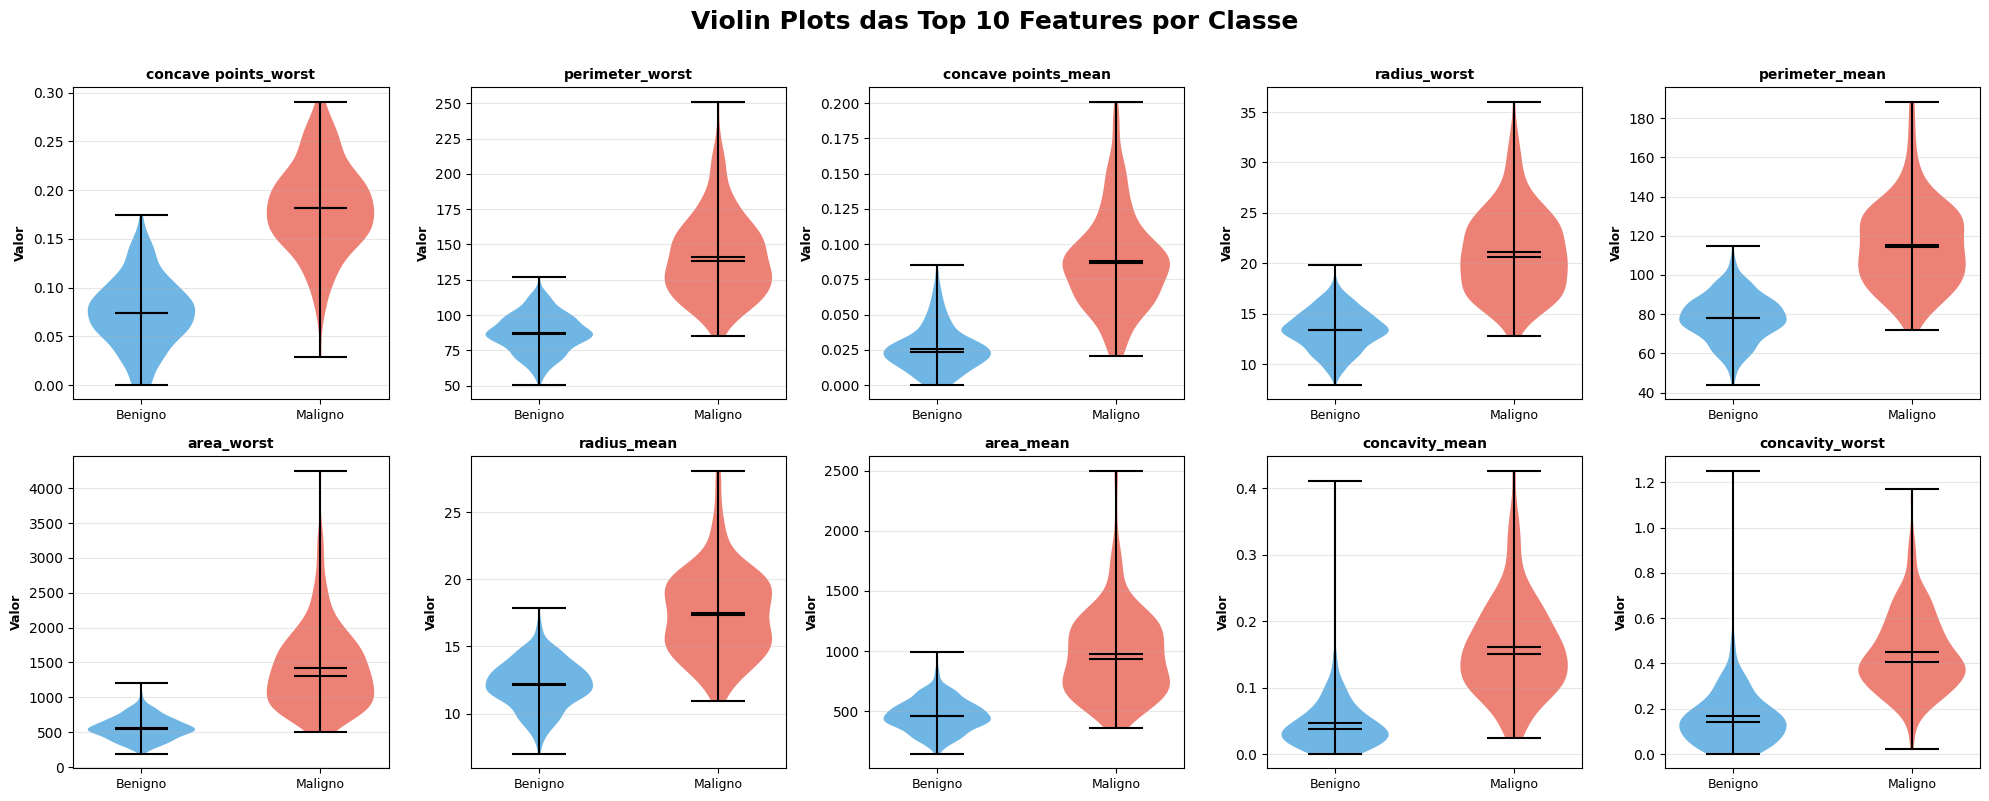

In [333]:
# Violin plots das top 10 features - complementa boxplots
# Mostra a distribuição completa (densidade) além dos quartis
top_10_features = correlation_with_target.head(10).index.tolist()

# Criar violin plots em grid 2x5
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Violin Plots das Top 10 Features por Classe', 
              fontweight='bold', fontsize=18, y=0.995)

axes = axes.flatten()

for idx, feature in enumerate(top_10_features):
    data_benign = df[df['diagnosis'] == 'B'][feature]
    data_malignant = df[df['diagnosis'] == 'M'][feature]
    parts = axes[idx].violinplot([data_benign, data_malignant], positions=[0, 1], 
                                  widths=0.6, showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.7)
    parts['bodies'][1].set_facecolor('#e74c3c')
    parts['bodies'][1].set_alpha(0.7)
    
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans', 'cmedians'):
        if partname in parts:
            parts[partname].set_color('black')
            parts[partname].set_linewidth(1.5)
    
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=9)
    axes[idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


Analisando os gráficos:

1. Boxplots

São gráficos que mostram a distribuição dos dados, exibindo a mediana, quartis e outliers:
- Se as caixas de Benigno e Maligno estão separadas, a feature é útil para classificação
- Se as caixas estão sobrepostas, a feature tem menor poder discriminativo**

2. Histogramas

- Se os histogramas de Benigno e Maligno estão separados, então é uma boa feature para classificação
- Se estão sobrepostos, a feature tende a ser menos discriminativa
- Áreas de sobreposição, é uma região de incerteza onde é difícil distinguir as classes

3. Correlação com o Diagnóstico

A correlação mede a relação linear entre duas variáveis, neste caso, entre uma feature e o diagnóstico.

- Correlação alta (próximo de +1 ou -1) = forte relação linear
- Correlação baixa (próximo de 0) = pouca ou nenhuma relação linear

Portanto:
- Features com alta correlação com o diagnóstico são mais importantes para o modelo
- Essas features ajudam a prever se um tumor é benigno ou maligno
- Correlação positiva: Quando a feature aumenta, maior probabilidade de ser Maligno (M)
- Correlação negativa: Quando a feature aumenta, maior probabilidade de ser Benigno (B)

A separação entre classes indica o quão bem uma feature consegue distinguir entre tumores benignos e malignos.

Características de boa separação:
- Boxplots com caixas separadas (pouca sobreposição)
- Histogramas com picos em posições diferentes
- Área de sobreposição mínima entre as distribuições

Características de má separação:
- Boxplots com muita sobreposição
- Histogramas sobrepostos com picos similares
- Área de sobreposição grande, portanto, difícil distinguir as classes

A variabilidade mede o quanto os valores variam dentro de cada classe.
- Baixa variabilidade = valores consistentes dentro da classe (boxplot com caixa pequena)
- Alta variabilidade = valores muito diferentes (boxplot com caixa grande)
- Baixa variabilidade dentro da classe e com boa separação entre classes = feature ideal

4. Violin Plots

São gráficos que combinam informações de boxplots com a distribuição de densidade dos dados:
- Mostram a distribuição completa (densidade) além dos quartis e mediana
- Complementam os boxplots ao exibir a forma da distribuição de probabilidade
- A largura do violino em cada ponto indica a frequência relativa dos valores nessa região
- Se os violinos de Benigno e Maligno têm formas diferentes e estão separados, a feature é útil para classificação
- Violinos sobrepostos indicam menor poder discriminativo da feature
- Permitem identificar multimodalidade e assimetrias na distribuição dos dados



Conclusão da Análise Exploratória dos Dados

Com base na análise exploratória realizada, podemos tirar as seguintes conclusões sobre o dataset de câncer de mama:

1. Características Gerais do Dataset

O dataset possui 569 amostras e 30 features numéricas que descrevem características das células de tumores de mama. As features representam três tipos de medidas para cada característica: média (mean), erro padrão (se) e pior valor (worst), resultando em 30 características no total.

Não foram encontrados valores ausentes no dataset, o que indica uma base de dados limpa e pronta para análise e modelagem.

2. Distribuição das Classes

O dataset apresenta um desbalanceamento moderado entre as classes:
- 357 casos benignos (62.74%)
- 212 casos malignos (37.26%)
- Razão de balanceamento: 0.59

Embora exista um desbalanceamento, a razão de 0.59 indica que não é crítico, mas deve ser considerado durante a modelagem para evitar viés em favor da classe majoritária (benigna).

3. Qualidade das Features para Classificação

As análises gráficas (boxplots, histogramas e violin plots) revelaram que as 10 features mais correlacionadas apresentam boa separação entre as classes benignas e malignas:
- Features como concave points_worst, perimeter_worst, concave points_mean e radius_worst mostram correlações acima de 0.77 com o diagnóstico
- Os gráficos evidenciam separação clara entre as distribuições das duas classes
- Boxplots com pouca sobreposição indicam features discriminativas
- Histogramas com picos em posições diferentes confirmam a capacidade de distinção entre classes

4. Correlação entre Features

A análise de correlação identificou:
- Features com alta correlação entre si, indicando possível multicolinearidade (como radius, perimeter e area, que são relacionadas geometricamente)
- Features com alta correlação com o target (diagnóstico), essenciais para o modelo preditivo
- O heatmap completo permite identificar grupos de features similares que podem ser redundantes

5. Escalas dos Dados

As features apresentam escalas muito diferentes entre si, o que indica a necessidade de padronização ou normalização antes da aplicação de modelos de Machine Learning sensíveis à escala, como regressão logística, SVM e redes neurais.



In [334]:
# Importar bibliotecas de pré-processamento do scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [335]:
# Separar features 
X = df.drop(columns=['diagnosis'])  # Remove a coluna de diagnóstico
y = df['diagnosis']  # Alvo


print(f"Features (X):")
print(f"Forma: {X.shape}")
print(f"Quantidade de features: {X.shape[1]}")
print(f"Target (y):")
print(f"{y.shape}")
print(f"Valores únicos: {y.unique()}")
print(f"Distribuição:")
print(y.value_counts())


Features (X):
Forma: (569, 30)
Quantidade de features: 30
Target (y):
(569,)
Valores únicos: ['M' 'B']
Distribuição:
diagnosis
B    357
M    212
Name: count, dtype: int64


Convertendo as colunas categóricas em numéricas:


In [336]:
# Converter target para valores numéricos
y = y.map({'B': 0, 'M': 1})
print(f"Valores únicos: {y.unique()}")
print(f"Distribuição:")
print(y.value_counts().sort_index())


Valores únicos: [1 0]
Distribuição:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [337]:
# Obtem os nomes das colunas numéricas
numeric_features = X.columns.tolist()

# Cria o pré-processador usando ColumnTransformer
# Aplicação do StandardScaler em todas as features numéricas (padronização)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)
print(f"Features processadas: {len(numeric_features)}")


Features processadas: 30


In [338]:
# Importar train_test_split
from sklearn.model_selection import train_test_split

# Separar dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,                   
    y,                    
    test_size=0.2,        
    stratify=y,           
    random_state=42       
)

print(f"Dados de treino:")
print(y_train.value_counts().sort_index())

print(f"Conjunto de TESTE:")
print(y_test.value_counts().sort_index())

preprocessor.fit(X_train)
X_train_scaled = preprocessor.transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

Dados de treino:
diagnosis
0    285
1    170
Name: count, dtype: int64
Conjunto de TESTE:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [339]:
# Verificando padronização
import numpy as np

train_means = np.mean(X_train_scaled, axis=0)
print(f"Média das médias: {np.mean(train_means):.6f}")
print(f"Min média: {np.min(train_means):.6f}, Max média: {np.max(train_means):.6f}")

train_stds = np.std(X_train_scaled, axis=0)
print(f"Média dos desvios padrão: {np.mean(train_stds):.6f}")
print(f"Min desvio padrão: {np.min(train_stds):.6f}, Max desvio padrão: {np.max(train_stds):.6f}")

Média das médias: 0.000000
Min média: -0.000000, Max média: 0.000000
Média dos desvios padrão: 1.000000
Min desvio padrão: 1.000000, Max desvio padrão: 1.000000


In [340]:
error = [] #armazenar os erros

# Calculating error for K values between 1 and 15
for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)

    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

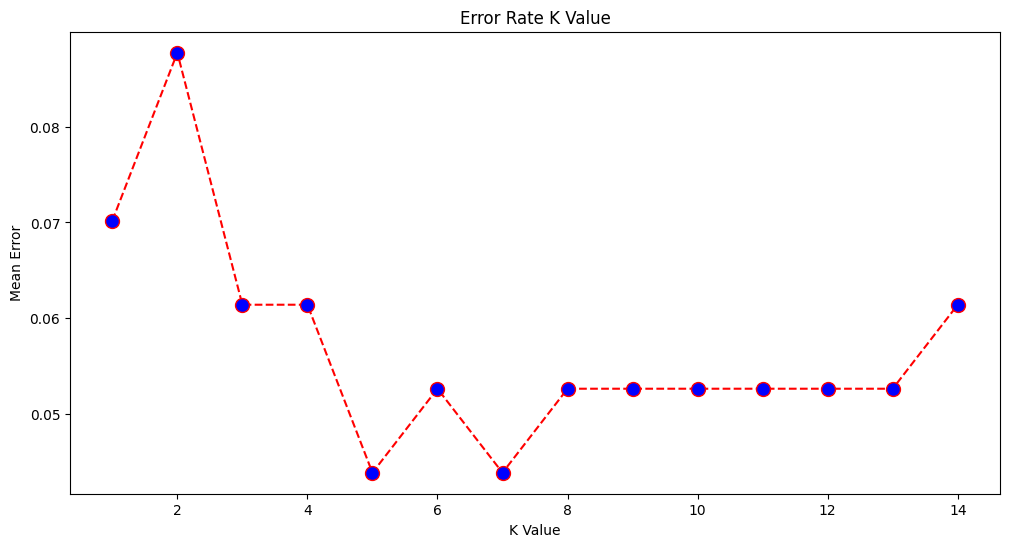

In [341]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

Utilizamos o metodo para seleção dos melhores Ks 

In [342]:
model_classifier = KNeighborsClassifier(n_neighbors=5)
model_classifier.fit(X_train_scaled, y_train)
predict_knn = model_classifier.predict(X_test_scaled)

Usando a regressão logística para verificação.



In [343]:
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_train_scaled, y_train)
predict_lr = lr_classifier.predict(X_test_scaled)

Matriz de Confusão - Regressão Logística


<Figure size 1500x500 with 0 Axes>

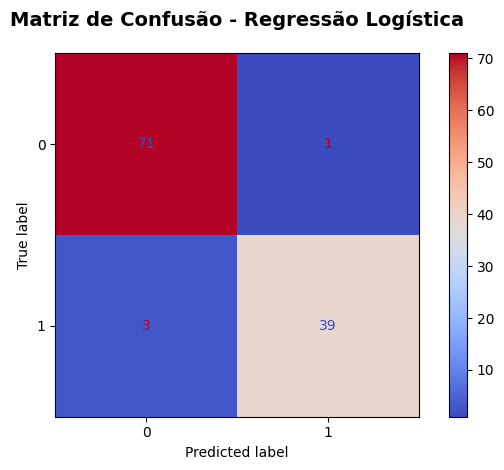

In [344]:
confusion_matrix_lr = confusion_matrix(y_true=y_test,
                                       y_pred=predict_lr,
                                       labels=[0, 1])

figure = plt.figure(figsize=(15, 5))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_lr,
                                  display_labels=[0, 1])
disp_lr.plot(values_format='d', cmap='coolwarm')
plt.title('Matriz de Confusão - Regressão Logística', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [345]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_lr = accuracy_score(y_test, predict_lr)
print(classification_report(y_test, predict_lr, 
                           target_names=['Benigno (B)', 'Maligno (M)'],
                           digits=4))


              precision    recall  f1-score   support

 Benigno (B)     0.9595    0.9861    0.9726        72
 Maligno (M)     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



Matriz de Confusão - KNN



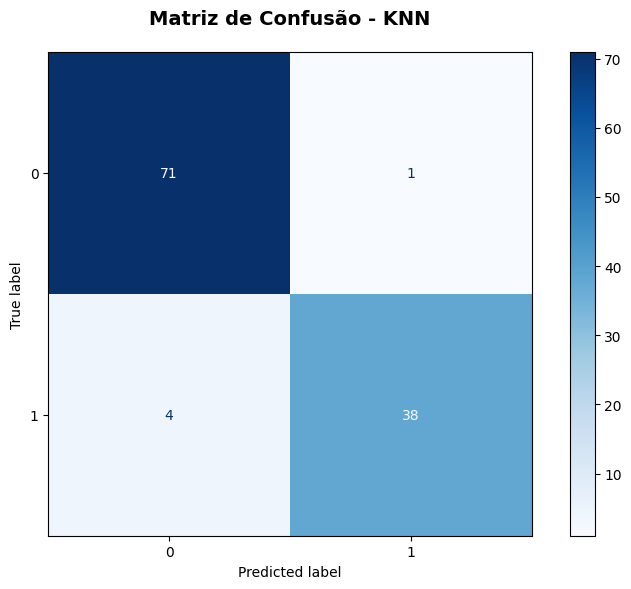

Matriz de Confusão - KNN:
[[71  1]
 [ 4 38]]


In [346]:
confusion_matrix_knn = confusion_matrix(y_true=y_test,
                                        y_pred=predict_knn,
                                        labels=[0, 1])

# Plotando uma figura com a matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp_knn = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_knn,
                                   display_labels=[0, 1])
disp_knn.plot(ax=ax, values_format='d', cmap='Blues')
plt.title('Matriz de Confusão - KNN', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Matriz de Confusão - KNN:")
print(confusion_matrix_knn) 

In [347]:
# Métricas do KNN
accuracy_knn = accuracy_score(y_test, predict_knn)
print(f"\nAcurácia KNN: {accuracy_knn:.4f}\n")
print(classification_report(y_test, predict_knn, 
                           target_names=['Benigno (B)', 'Maligno (M)'],
                           digits=4))


Acurácia KNN: 0.9561

              precision    recall  f1-score   support

 Benigno (B)     0.9467    0.9861    0.9660        72
 Maligno (M)     0.9744    0.9048    0.9383        42

    accuracy                         0.9561       114
   macro avg     0.9605    0.9454    0.9521       114
weighted avg     0.9569    0.9561    0.9558       114



In [348]:
# Validação Cruzada - KNN
print("Validação Cruzada - KNN")
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
knn_cv = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

print(f"Scores individuais: {knn_scores}")
print(f"Média: {knn_scores.mean():.4f}")
print(f"Desvio Padrão: {knn_scores.std():.4f}")
print(f"Score Mínimo: {knn_scores.min():.4f}")
print(f"Score Máximo: {knn_scores.max():.4f}")

Validação Cruzada - KNN
Scores individuais: [0.97826087 0.97826087 0.97826087 0.97826087 0.97826087 0.97777778
 0.95555556 0.95555556 0.91111111 0.97777778]
Média: 0.9669
Desvio Padrão: 0.0206
Score Mínimo: 0.9111
Score Máximo: 0.9783


In [349]:
# Validação Cruzada - Regressão Logística
print("Validação Cruzada - Regressão Logística")
lr_cv = LogisticRegression(random_state=42, max_iter=1000)
lr_scores = cross_val_score(lr_cv, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f"Scores individuais: {lr_scores}")
print(f"Média: {lr_scores.mean():.4f}")
print(f"Desvio Padrão: {lr_scores.std():.4f}")
print(f"Score Mínimo: {lr_scores.min():.4f}")
print(f"Score Máximo: {lr_scores.max():.4f}")


Validação Cruzada - Regressão Logística
Scores individuais: [1.         0.93478261 0.97826087 0.95652174 1.         1.
 0.97777778 0.97777778 0.91111111 1.        ]
Média: 0.9736
Desvio Padrão: 0.0292
Score Mínimo: 0.9111
Score Máximo: 1.0000


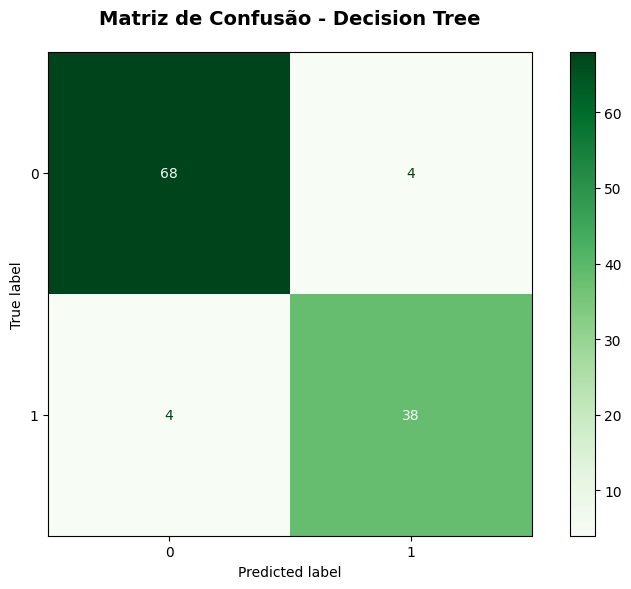


Acurácia Decision Tree: 0.9298

              precision    recall  f1-score   support

 Benigno (B)     0.9444    0.9444    0.9444        72
 Maligno (M)     0.9048    0.9048    0.9048        42

    accuracy                         0.9298       114
   macro avg     0.9246    0.9246    0.9246       114
weighted avg     0.9298    0.9298    0.9298       114



In [350]:
# Árvore de Decisão
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_classifier.fit(X_train_scaled, y_train)
predict_dt = dt_classifier.predict(X_test_scaled)

# Matriz de Confusão
confusion_matrix_dt = confusion_matrix(y_true=y_test,
                                        y_pred=predict_dt,
                                        labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_dt,
                                   display_labels=[0, 1])
disp_dt.plot(ax=ax, values_format='d', cmap='Greens')
plt.title('Matriz de Confusão - Decision Tree', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Métricas
accuracy_dt = accuracy_score(y_test, predict_dt)
print(f"\nAcurácia Decision Tree: {accuracy_dt:.4f}\n")
print(classification_report(y_test, predict_dt, 
                           target_names=['Benigno (B)', 'Maligno (M)'],
                           digits=4))

In [351]:
# Validação Cruzada - Decision Tree
print("Validação Cruzada - Decision Tree")
dt_cv = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_scores = cross_val_score(dt_cv, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

print(f"Scores individuais: {dt_scores}")
print(f"Média: {dt_scores.mean():.4f}")
print(f"Desvio Padrão: {dt_scores.std():.4f}")
print(f"Score Mínimo: {dt_scores.min():.4f}")
print(f"Score Máximo: {dt_scores.max():.4f}")


Validação Cruzada - Decision Tree
Scores individuais: [0.93478261 0.91304348 0.91304348 0.91304348 0.97826087 0.86666667
 1.         0.91111111 0.91111111 0.93333333]
Média: 0.9274
Desvio Padrão: 0.0358
Score Mínimo: 0.8667
Score Máximo: 1.0000


As 10 features mais importantes - DECISION TREE
             feature  importance
     perimeter_worst    0.727477
concave points_worst    0.078970
    smoothness_worst    0.040833
        texture_mean    0.037871
       texture_worst    0.022545
           area_mean    0.022452
        radius_worst    0.017530
          area_worst    0.015606
 concave points_mean    0.013416
        concavity_se    0.007043


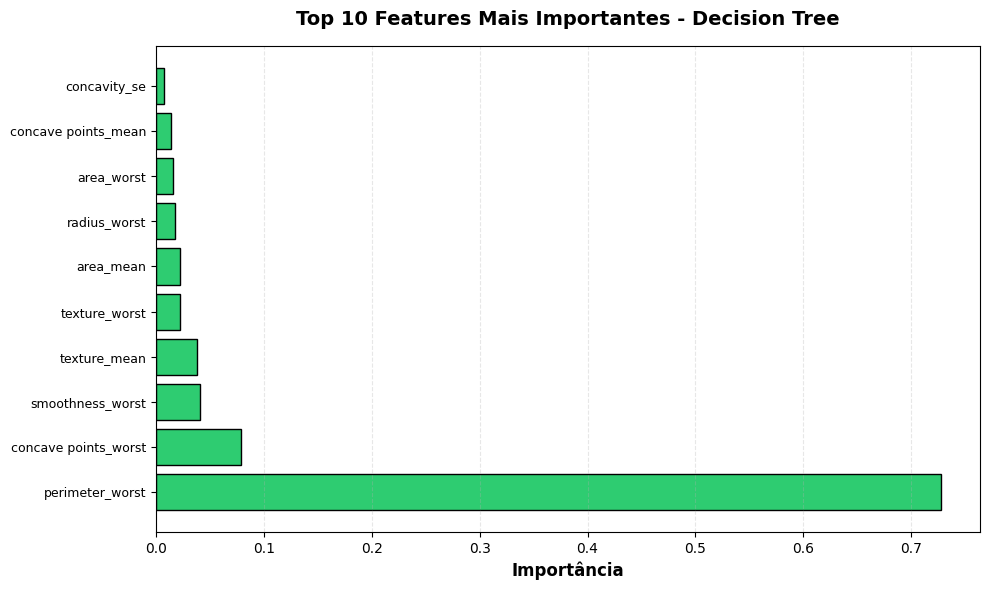

In [352]:
# Feature Importance - Decision Tree
feature_importance_dt = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("As 10 features mais importantes - DECISION TREE")
print(feature_importance_dt.head(10).to_string(index=False))

# Visualização das top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_10_dt = feature_importance_dt.head(10)
ax.barh(range(len(top_10_dt)), top_10_dt['importance'].values, color='#2ecc71', edgecolor='black')
ax.set_yticks(range(len(top_10_dt)))
ax.set_yticklabels(top_10_dt['feature'].values, fontsize=9)
ax.set_xlabel('Importância', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Features Mais Importantes - Decision Tree', 
             fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Random Forest


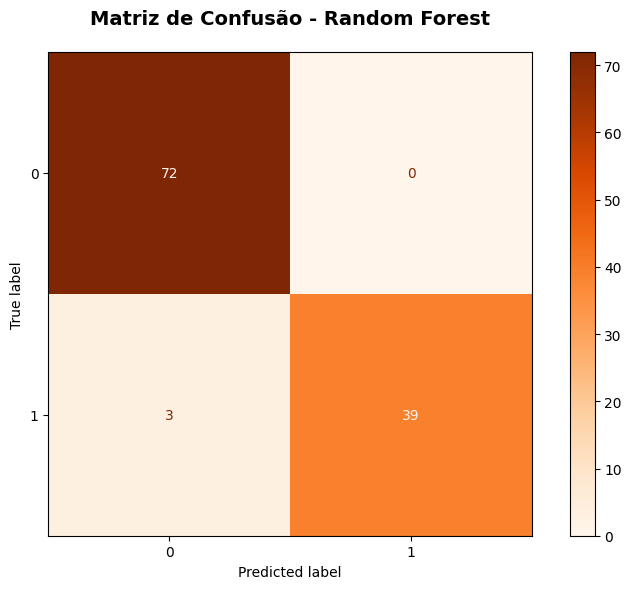


Acurácia: 0.9737

              precision    recall  f1-score   support

 Benigno (B)     0.9600    1.0000    0.9796        72
 Maligno (M)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



In [353]:
# Random Forest
print("Random Forest")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_train_scaled, y_train)
predict_rf = rf_classifier.predict(X_test_scaled)

# Matriz de Confusão
confusion_matrix_rf = confusion_matrix(y_true=y_test,
                                       y_pred=predict_rf,
                                       labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_rf,
                                  display_labels=[0, 1])
disp_rf.plot(ax=ax, values_format='d', cmap='Oranges')
plt.title('Matriz de Confusão - Random Forest', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Métricas
accuracy_rf = accuracy_score(y_test, predict_rf)
print(f"\nAcurácia: {accuracy_rf:.4f}\n")
print(classification_report(y_test, predict_rf, 
                           target_names=['Benigno (B)', 'Maligno (M)'],
                           digits=4))


In [354]:
# Validação Cruzada - Random Forest
print("Validação Cruzada - Random Forest")
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_scores = cross_val_score(rf_cv, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

print(f"Média: {rf_scores.mean():.4f}")
print(f"Desvio Padrão: {rf_scores.std():.4f}")
print(f"Score Mínimo: {rf_scores.min():.4f}")


Validação Cruzada - Random Forest
Média: 0.9581
Desvio Padrão: 0.0232
Score Mínimo: 0.9333


As 10 features mais importantes - RANDOM FOREST
             feature  importance
          area_worst    0.151412
concave points_worst    0.126497
        radius_worst    0.093475
     perimeter_worst    0.083642
 concave points_mean    0.081082
      perimeter_mean    0.077126
         radius_mean    0.061990
      concavity_mean    0.050818
           area_mean    0.045916
     concavity_worst    0.030022


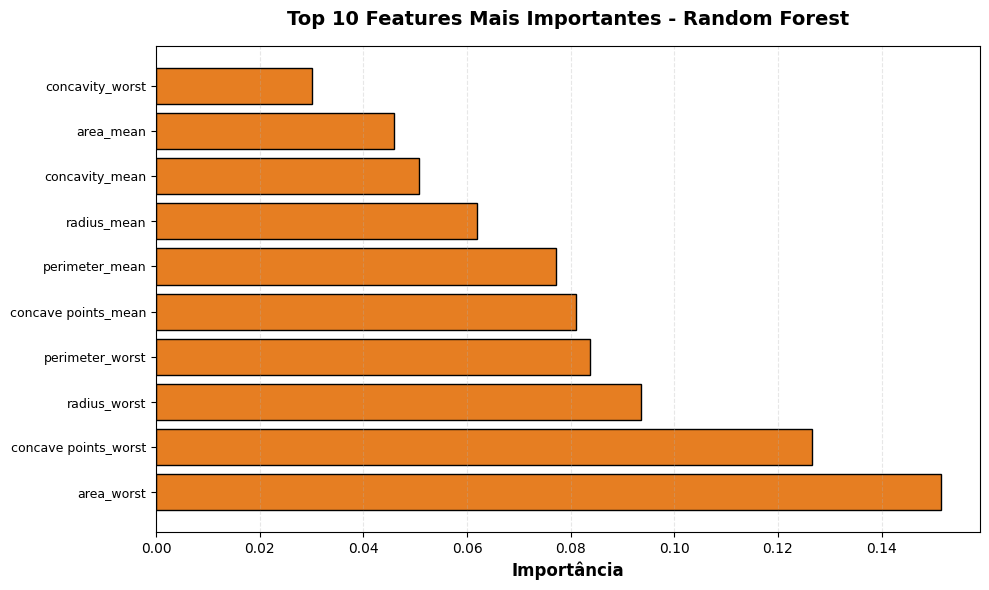

In [355]:
# Feature Importance - Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("As 10 features mais importantes - RANDOM FOREST")
print(feature_importance_rf.head(10).to_string(index=False))

# Visualização das top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_10_rf = feature_importance_rf.head(10)
ax.barh(range(len(top_10_rf)), top_10_rf['importance'].values, color='#e67e22', edgecolor='black')
ax.set_yticks(range(len(top_10_rf)))
ax.set_yticklabels(top_10_rf['feature'].values, fontsize=9)
ax.set_xlabel('Importância', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Features Mais Importantes - Random Forest', 
             fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


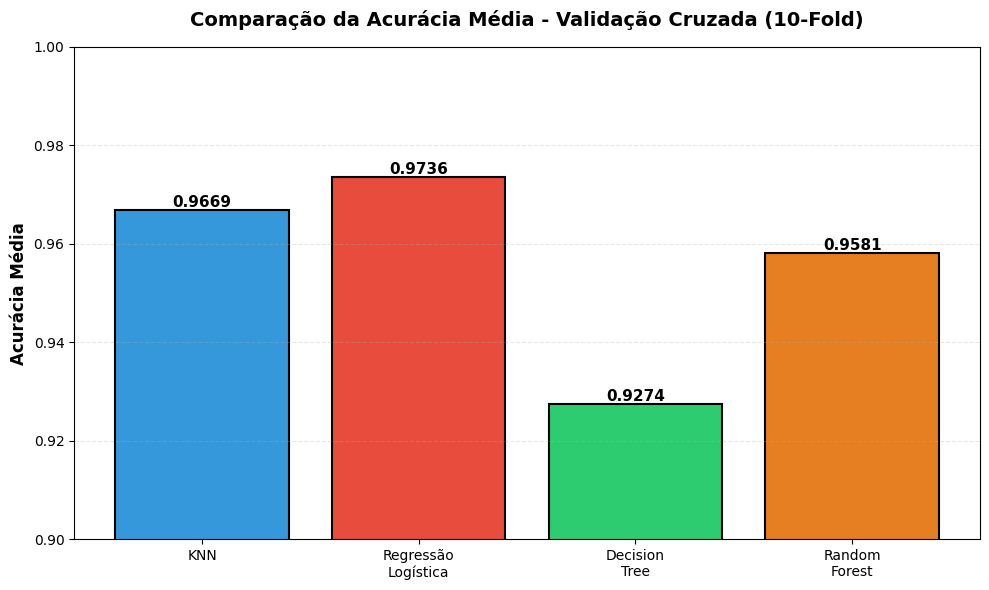

In [356]:
# Comparação Visual - Validação Cruzada
knn_scores = np.array(knn_scores)
lr_scores = np.array(lr_scores)
dt_scores = np.array(dt_scores)
rf_scores = np.array(rf_scores)

models = ['KNN', 'Regressão\nLogística', 'Decision\nTree', 'Random\nForest']
means = [knn_scores.mean(), lr_scores.mean(), dt_scores.mean(), rf_scores.mean()]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22']
bars = ax.bar(models, means, color=colors, edgecolor='black', linewidth=1.5)

# Valores no topo das barras
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{mean:.4f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Acurácia Média', fontsize=12, fontweight='bold')
ax.set_title('Comparação da Acurácia Média - Validação Cruzada (10-Fold)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0.90, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/tt/tgl534sn4754ph9vt3prw4tc0000gn/T/ipykernel_76923/371428969.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=['KNN', 'Regressão\nLogística', 'Decision\nTree', 'Random\nForest'],


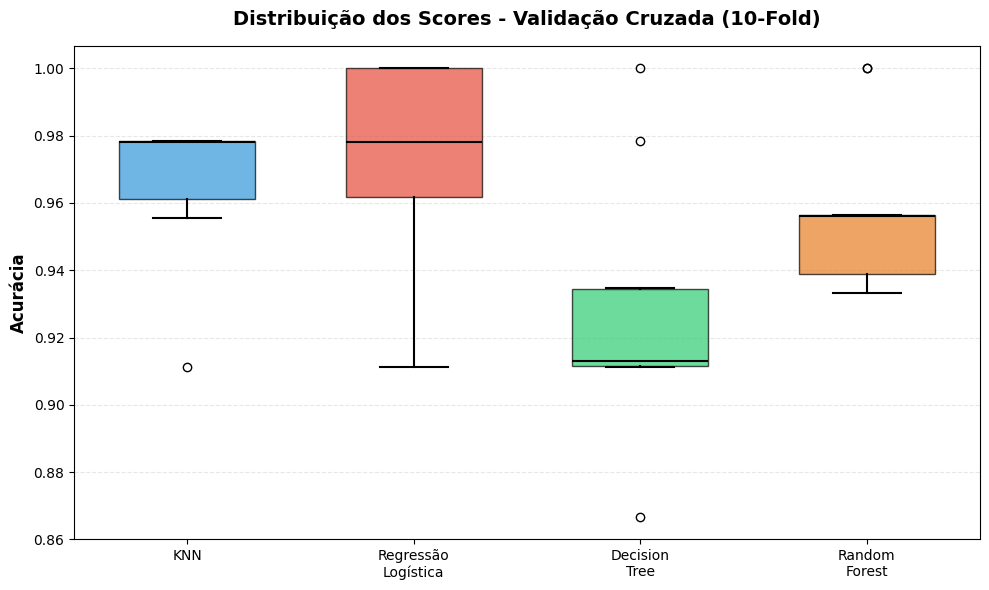

In [357]:
# Boxplot Comparativo - Validação Cruzada
fig, ax = plt.subplots(figsize=(10, 6))
boxplot_data = [knn_scores, lr_scores, dt_scores, rf_scores]
bp = ax.boxplot(boxplot_data, labels=['KNN', 'Regressão\nLogística', 'Decision\nTree', 'Random\nForest'],
                patch_artist=True, widths=0.6)

# Cores para cada boxplot
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='black', linewidth=1.5)

ax.set_ylabel('Acurácia', fontsize=12, fontweight='bold')
ax.set_title('Distribuição dos Scores - Validação Cruzada (10-Fold)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Uso do GridSearchCV para melhorar a performance dos modelos ao encontrar a melhor combinação de parâmetros.

Agora vamos otimizar os hiperparâmetros de cada modelo usando GridSearchCV. Isso vai melhorar significativamente a performance dos modelos ao encontrar a melhor combinação de parâmetros.


In [358]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_base = KNeighborsClassifier()
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_knn.fit(X_train_scaled, y_train)

#exibição dos melhores hiperparâmetros
for param, value in grid_search_knn.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nMelhor score (média na validação cruzada): {grid_search_knn.best_score_:.4f}")
print(f"Score no conjunto de teste: {grid_search_knn.score(X_test_scaled, y_test):.4f}")

# Treino do modelo otimizado
knn_optimized = grid_search_knn.best_estimator_
predict_knn_opt = knn_optimized.predict(X_test_scaled)
accuracy_knn_opt = accuracy_score(y_test, predict_knn_opt)

print(f"\nAcurácia: {accuracy_knn_opt:.4f}")
print(f"Comparação: {((accuracy_knn_opt - accuracy_knn) / accuracy_knn * 100):.2f}%")


Fitting 10 folds for each of 36 candidates, totalling 360 fits
   metric: manhattan
   n_neighbors: 3
   weights: uniform

Melhor score (média na validação cruzada): 0.9735
Score no conjunto de teste: 0.9649

Acurácia: 0.9649
Comparação: 0.92%


In [359]:
# GridSearchCV para a Regressão Logística
param_grid_lr = [
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'] #'l1' penalty só funciona com 'liblinear' e 'saga'
    },
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs'] #'l2' funciona com 'liblinear', 'lbfgs', 'newton-cg', 'saga'
    }
]

lr_base = LogisticRegression(random_state=42, max_iter=1000)
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train_scaled, y_train)

#exibição dos melhores hiperparâmetros
for param, value in grid_search_lr.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nMelhor score (média na validação cruzada): {grid_search_lr.best_score_:.4f}")
print(f"Score no conjunto de teste: {grid_search_lr.score(X_test_scaled, y_test):.4f}")

# Treino do modelo otimizado
lr_optimized = grid_search_lr.best_estimator_
predict_lr_opt = lr_optimized.predict(X_test_scaled)
accuracy_lr_opt = accuracy_score(y_test, predict_lr_opt)

print(f"\nAcurácia: {accuracy_lr_opt:.4f}")
print(f"Comparação: {((accuracy_lr_opt - accuracy_lr) / accuracy_lr * 100):.2f}%")


Fitting 10 folds for each of 18 candidates, totalling 180 fits
   C: 1
   penalty: l1
   solver: liblinear

Melhor score (média na validação cruzada): 0.9780
Score no conjunto de teste: 0.9737

Acurácia: 0.9737
Comparação: 0.91%


In [360]:
# GridSearchCV para a Decision Tree
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train_scaled, y_train)

#exibição dos melhores hiperparâmetros
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nMelhor score (média na validação cruzada): {grid_search_dt.best_score_:.4f}")
print(f"Score no conjunto de teste: {grid_search_dt.score(X_test_scaled, y_test):.4f}")

# Treino do modelo otimizado
dt_optimized = grid_search_dt.best_estimator_
predict_dt_opt = dt_optimized.predict(X_test_scaled)
accuracy_dt_opt = accuracy_score(y_test, predict_dt_opt)

print(f"\nAcurácia: {accuracy_dt_opt:.4f}")
print(f"Comparação: {((accuracy_dt_opt - accuracy_dt) / accuracy_dt * 100):.2f}%")


Fitting 10 folds for each of 160 candidates, totalling 1600 fits
   criterion: entropy
   max_depth: 5
   min_samples_leaf: 2
   min_samples_split: 2

Melhor score (média na validação cruzada): 0.9471
Score no conjunto de teste: 0.9649

Acurácia: 0.9649
Comparação: 3.77%


In [361]:
# GridSearchCV para o Random Forest

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_scaled, y_train)

#exibição dos melhores hiperparâmetros
for param, value in grid_search_rf.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nMelhor score (média na validação cruzada): {grid_search_rf.best_score_:.4f}")
print(f"Score no conjunto de teste: {grid_search_rf.score(X_test_scaled, y_test):.4f}")

# Treino do modelo otimizado
rf_optimized = grid_search_rf.best_estimator_
predict_rf_opt = rf_optimized.predict(X_test_scaled)
accuracy_rf_opt = accuracy_score(y_test, predict_rf_opt)

print(f"\nAcurácia: {accuracy_rf_opt:.4f}")
print(f"Comparação: {((accuracy_rf_opt - accuracy_rf) / accuracy_rf * 100):.2f}%")


Fitting 10 folds for each of 135 candidates, totalling 1350 fits
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 5
   n_estimators: 50

Melhor score (média na validação cruzada): 0.9625
Score no conjunto de teste: 0.9649

Acurácia: 0.9649
Comparação: -0.90%


             Modelo    Antes   Depois  Melhoria  Melhoria_abs
                KNN 0.956140 0.964912      0.92        0.0088
Regressão Logística 0.964912 0.973684      0.91        0.0088
      Decision Tree 0.929825 0.964912      3.77        0.0351
      Random Forest 0.973684 0.964912     -0.90       -0.0088


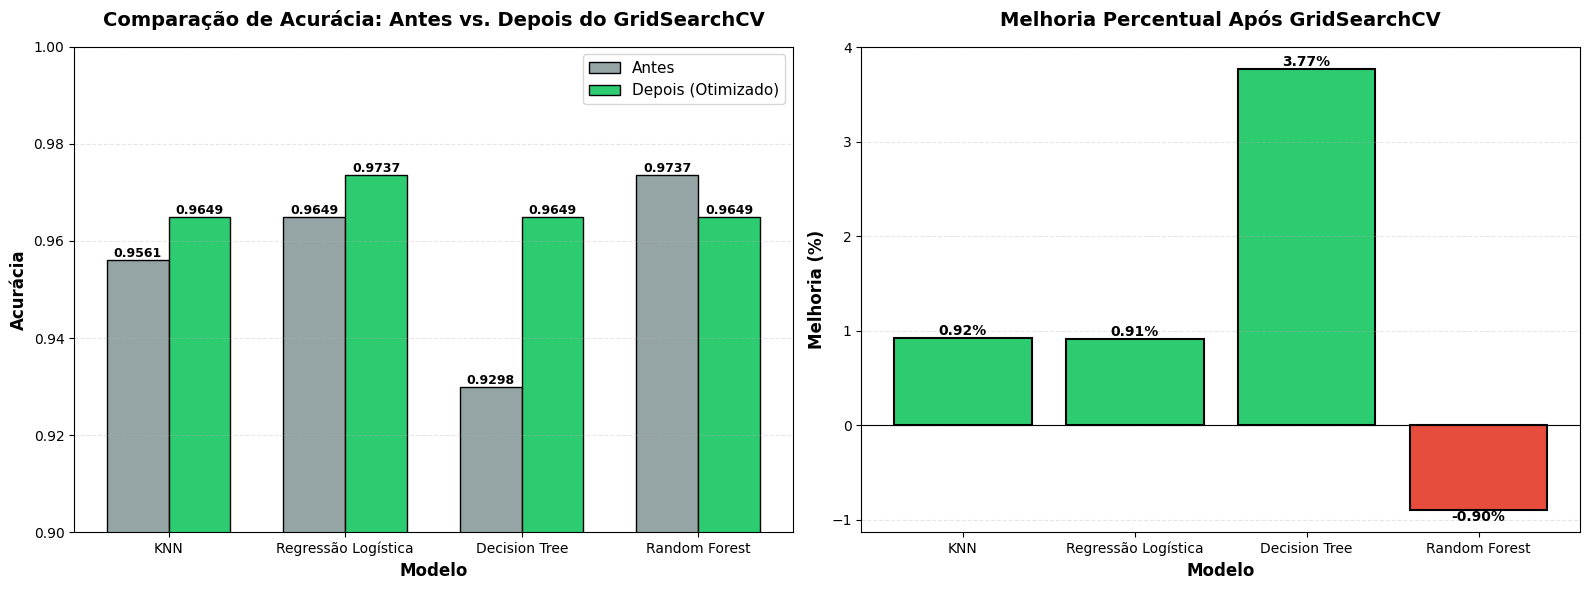

In [362]:
# Comparação com os modelos antes e depois do GridSearch
comparison_data = {
    'Modelo': ['KNN', 'Regressão Logística', 'Decision Tree', 'Random Forest'],
    'Antes': [accuracy_knn, accuracy_lr, accuracy_dt, accuracy_rf],
    'Depois': [accuracy_knn_opt, accuracy_lr_opt, accuracy_dt_opt, accuracy_rf_opt]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Melhoria'] = ((comparison_df['Depois'] - comparison_df['Antes']) / comparison_df['Antes'] * 100).round(2)
comparison_df['Melhoria_abs'] = (comparison_df['Depois'] - comparison_df['Antes']).round(4)
print(comparison_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparação de Acurácia
x = np.arange(len(comparison_df['Modelo']))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Antes'], width, label='Antes', color='#95a5a6', edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_df['Depois'], width, label='Depois (Otimizado)', color='#2ecc71', edgecolor='black')

ax1.set_xlabel('Modelo', fontweight='bold', fontsize=12)
ax1.set_ylabel('Acurácia', fontweight='bold', fontsize=12)
ax1.set_title('Comparação de Acurácia: Antes vs. Depois do GridSearchCV', 
              fontweight='bold', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Modelo'])
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0.90, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 2: Melhoria Percentual
colors_improvement = ['#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#95a5a6' 
                      for x in comparison_df['Melhoria']]
bars3 = ax2.bar(comparison_df['Modelo'], comparison_df['Melhoria'], 
                color=colors_improvement, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Modelo', fontweight='bold', fontsize=12)
ax2.set_ylabel('Melhoria (%)', fontweight='bold', fontsize=12)
ax2.set_title('Melhoria Percentual Após GridSearchCV', 
              fontweight='bold', fontsize=14, pad=15)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



Modelo                    Média (Antes)      Média (Depois)     Melhoria    
KNN                       0.9669             0.9735                   0.68%
Regressão Logística       0.9736             0.9780                   0.45%
Decision Tree             0.9274             0.9471                   2.13%
Random Forest             0.9581             0.9625                   0.46%


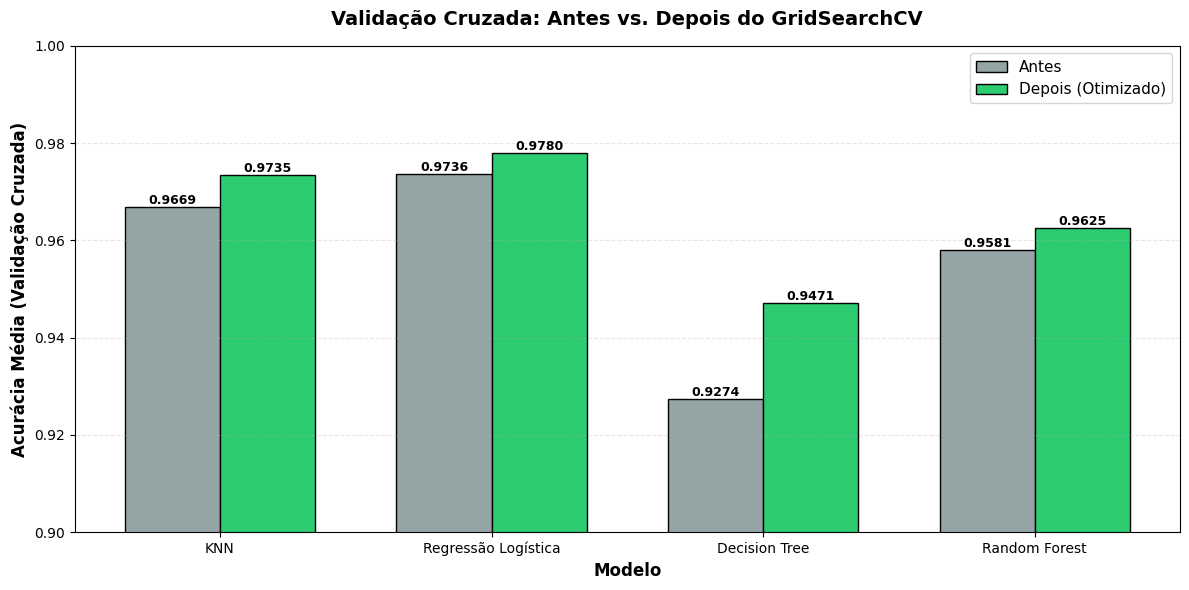

In [363]:
# Validação cruzada dos modelos otimizados
knn_scores_opt = cross_val_score(knn_optimized, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
lr_scores_opt = cross_val_score(lr_optimized, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
dt_scores_opt = cross_val_score(dt_optimized, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
rf_scores_opt = cross_val_score(rf_optimized, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

# Comparação
print(f"\n{'Modelo':<25} {'Média (Antes)':<18} {'Média (Depois)':<18} {'Melhoria':<12}")
print(f"{'KNN':<25} {knn_scores.mean():<18.4f} {knn_scores_opt.mean():<18.4f} {((knn_scores_opt.mean() - knn_scores.mean()) / knn_scores.mean() * 100):>10.2f}%")
print(f"{'Regressão Logística':<25} {lr_scores.mean():<18.4f} {lr_scores_opt.mean():<18.4f} {((lr_scores_opt.mean() - lr_scores.mean()) / lr_scores.mean() * 100):>10.2f}%")
print(f"{'Decision Tree':<25} {dt_scores.mean():<18.4f} {dt_scores_opt.mean():<18.4f} {((dt_scores_opt.mean() - dt_scores.mean()) / dt_scores.mean() * 100):>10.2f}%")
print(f"{'Random Forest':<25} {rf_scores.mean():<18.4f} {rf_scores_opt.mean():<18.4f} {((rf_scores_opt.mean() - rf_scores.mean()) / rf_scores.mean() * 100):>10.2f}%")

# Visualização comparativa
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Modelo']))
width = 0.35

bars1 = ax.bar(x - width/2, [knn_scores.mean(), lr_scores.mean(), dt_scores.mean(), rf_scores.mean()], 
               width, label='Antes', color='#95a5a6', edgecolor='black')
bars2 = ax.bar(x + width/2, [knn_scores_opt.mean(), lr_scores_opt.mean(), dt_scores_opt.mean(), rf_scores_opt.mean()], 
               width, label='Depois (Otimizado)', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Modelo', fontweight='bold', fontsize=12)
ax.set_ylabel('Acurácia Média (Validação Cruzada)', fontweight='bold', fontsize=12)
ax.set_title('Validação Cruzada: Antes vs. Depois do GridSearchCV', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0.90, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [364]:
# Resumo dos melhores hiperparâmetros
print("Melhores hiperparâmetros encontrados pelo GridSearchCV")
best_params_summary = {
    'KNN': (grid_search_knn.best_params_, grid_search_knn.best_score_),
    'Regressão Logística': (grid_search_lr.best_params_, grid_search_lr.best_score_),
    'Decision Tree': (grid_search_dt.best_params_, grid_search_dt.best_score_),
    'Random Forest': (grid_search_rf.best_params_, grid_search_rf.best_score_)
}

for model_name, (params, score) in best_params_summary.items():
    print(f"\n{model_name}:")
    print("-" * 60)
    for param, value in params.items():
        print(f"  {param:20s}: {value}")
    print(f"  {'Score CV':20s}: {score:.4f}")



Melhores hiperparâmetros encontrados pelo GridSearchCV

KNN:
------------------------------------------------------------
  metric              : manhattan
  n_neighbors         : 3
  weights             : uniform
  Score CV            : 0.9735

Regressão Logística:
------------------------------------------------------------
  C                   : 1
  penalty             : l1
  solver              : liblinear
  Score CV            : 0.9780

Decision Tree:
------------------------------------------------------------
  criterion           : entropy
  max_depth           : 5
  min_samples_leaf    : 2
  min_samples_split   : 2
  Score CV            : 0.9471

Random Forest:
------------------------------------------------------------
  max_depth           : 10
  min_samples_leaf    : 1
  min_samples_split   : 5
  n_estimators        : 50
  Score CV            : 0.9625


Vamos calcular o ROC (Receiver Operating Characteristic) e Precision-Recall para todos os modelos



In [365]:
# Obter probabilidades preditas (probabilidade da classe positiva - Maligno)
y_pred_proba_knn = knn_optimized.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_lr = lr_optimized.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_dt = dt_optimized.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_rf = rf_optimized.predict_proba(X_test_scaled)[:, 1]

print(f"Probabilidade de KNN: {y_pred_proba_knn}")
print(f"Probabilidade de Regressão Logística: {y_pred_proba_lr}")
print(f"Probabilidade de Decision Tree: {y_pred_proba_dt}")
print(f"Probabilidade de Random Forest: {y_pred_proba_rf}")



Probabilidade de KNN: [0.         1.         0.         0.66666667 0.         0.
 0.33333333 0.         0.         0.         1.         0.
 1.         0.         0.         0.         0.         0.
 0.33333333 0.         0.         0.         1.         1.
 1.         0.         0.         1.         1.         1.
 1.         0.         1.         1.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         1.         0.         0.66666667
 0.         0.         1.         1.         0.         0.
 0.         1.         0.         0.         0.         1.
 0.         0.         1.         0.         0.         0.
 1.         1.         0.         1.         0.         1.
 1.         0.         0.         0.33333333 0.         1.
 0.         0.66666667 1.         1.         0.         0.
 0.         0.         1.         1.         1.         0.
 1.         0.         0.33333333 0.         0.         0.
 0.         1.         0. 

In [366]:
# Calculo do ROC AUC para todos os modelos
print("Calculando ROC AUC para todos os modelos")
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

roc_auc_scores = {
    'KNN': roc_auc_knn,
    'Regressão Logística': roc_auc_lr,
    'Decision Tree': roc_auc_dt,
    'Random Forest': roc_auc_rf
}

print(f"\n{'Modelo':<25} {'ROC AUC':<12}")
for model, score in sorted(roc_auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {score:<12.4f}")

# Calculo das curvas ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

print(f"Melhor modelo (ROC AUC): {max(roc_auc_scores, key=roc_auc_scores.get)}")
print(f"Score: {max(roc_auc_scores.values()):.4f}")


Calculando ROC AUC para todos os modelos

Modelo                    ROC AUC     
Regressão Logística       0.9964      
Random Forest             0.9950      
KNN                       0.9735      
Decision Tree             0.9524      
Melhor modelo (ROC AUC): Regressão Logística
Score: 0.9964


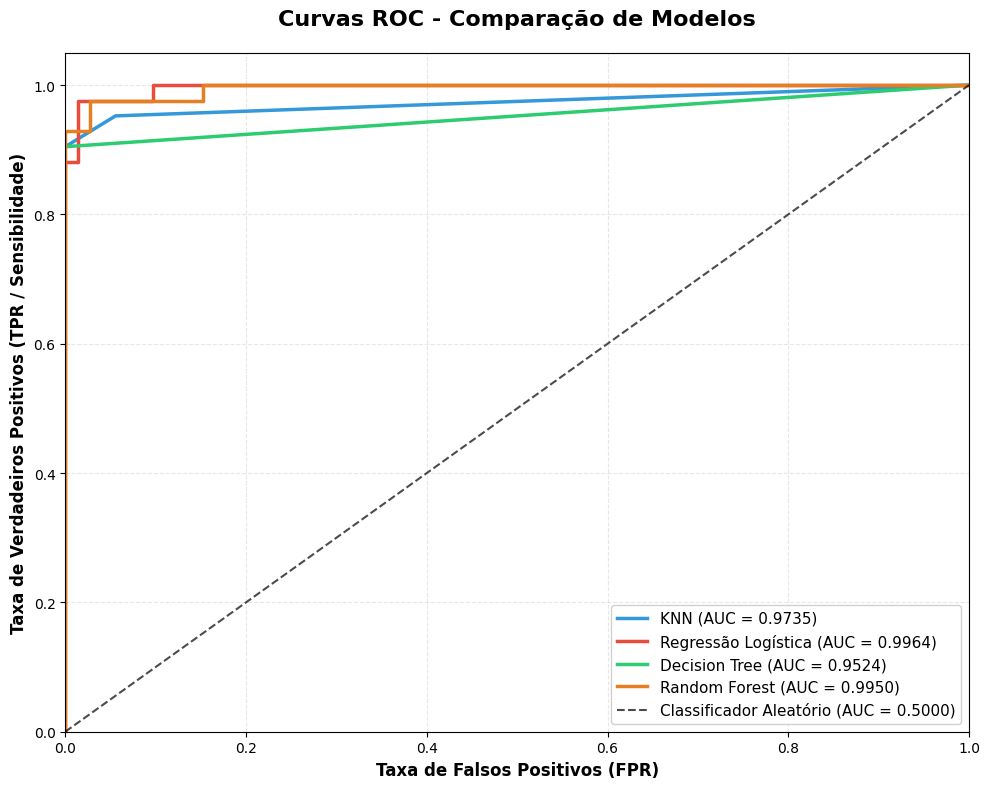


Interpretação:
   - Quanto mais próxima do canto superior esquerdo, melhor o modelo
   - AUC > 0.9: Excelente
   - AUC > 0.8: Bom
   - AUC > 0.7: Razoável
   - AUC = 0.5: Classificador aleatório (sem poder preditivo)


In [367]:
# Visualização das Curvas ROC
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', 
        color='#3498db', linewidth=2.5)
ax.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {roc_auc_lr:.4f})', 
        color='#e74c3c', linewidth=2.5)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})', 
        color='#2ecc71', linewidth=2.5)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', 
        color='#e67e22', linewidth=2.5)

# Linha diagonal para o classificador aleatório
ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.5000)', 
        linewidth=1.5, alpha=0.7)

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontweight='bold', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Sensibilidade)', 
              fontweight='bold', fontsize=12)
ax.set_title('Curvas ROC - Comparação de Modelos', 
             fontweight='bold', fontsize=16, pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("   - Quanto mais próxima do canto superior esquerdo, melhor o modelo")
print("   - AUC > 0.9: Excelente")
print("   - AUC > 0.8: Bom")
print("   - AUC > 0.7: Razoável")
print("   - AUC = 0.5: Classificador aleatório (sem poder preditivo)")


In [368]:
# Calcular Precision-Recall para todos os modelos
print("\n" + "="*80)
print("📊 PRECISION-RECALL CURVE E AVERAGE PRECISION")
print("="*80)

# Calcular Average Precision (AP) - área sob a curva Precision-Recall
print("Calculando Average Precision para todos os modelos")
ap_knn = average_precision_score(y_test, y_pred_proba_knn)
ap_lr = average_precision_score(y_test, y_pred_proba_lr)
ap_dt = average_precision_score(y_test, y_pred_proba_dt)
ap_rf = average_precision_score(y_test, y_pred_proba_rf)

ap_scores = {
    'KNN': ap_knn,
    'Regressão Logística': ap_lr,
    'Decision Tree': ap_dt,
    'Random Forest': ap_rf
}

print(f"\n{'Modelo':<25} {'Average Precision':<18}")
print("-"*80)
for model, score in sorted(ap_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {score:<18.4f}")
print("="*80)

# Calculo das curvas Precision-Recall
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_pred_proba_knn)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)

print(f"\nMelhor modelo (Average Precision): {max(ap_scores, key=ap_scores.get)}")
print(f"Score: {max(ap_scores.values()):.4f}")



📊 PRECISION-RECALL CURVE E AVERAGE PRECISION
Calculando Average Precision para todos os modelos

Modelo                    Average Precision 
--------------------------------------------------------------------------------
Regressão Logística       0.9942            
Random Forest             0.9928            
KNN                       0.9656            
Decision Tree             0.9398            

Melhor modelo (Average Precision): Regressão Logística
Score: 0.9942


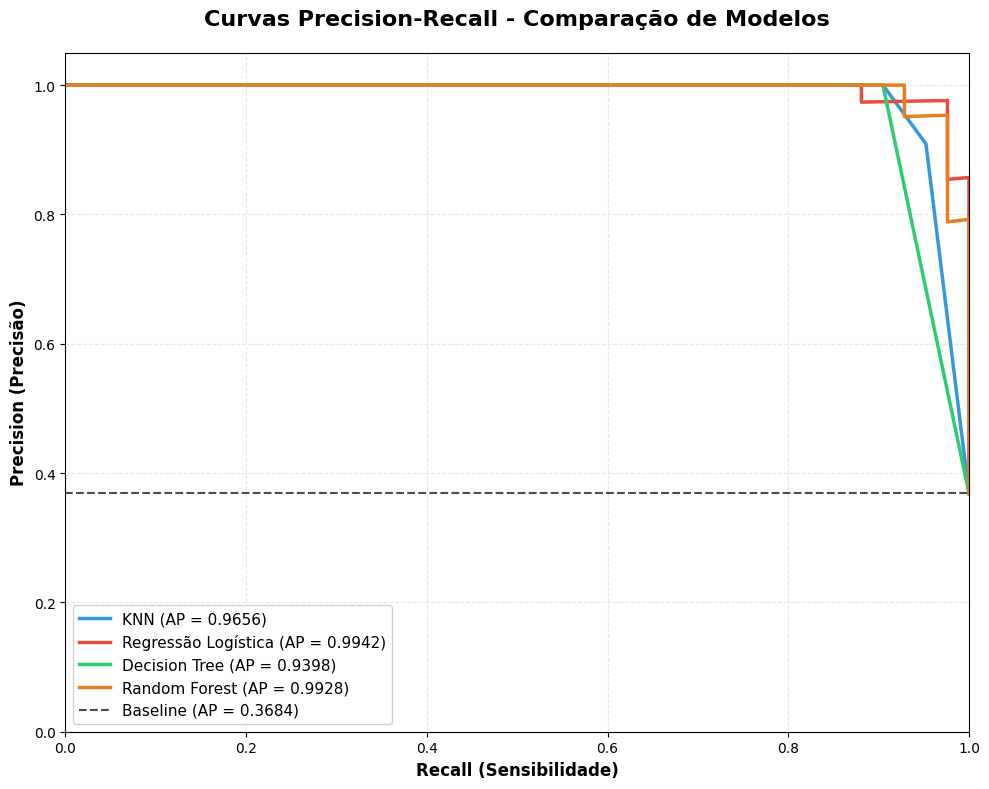


Interpretação:
   - Quanto mais próxima do canto superior direito, melhor o modelo
   - AP > 0.9: Excelente
   - AP > 0.8: Bom
   - AP > 0.7: Razoável
   - AP próximo ao baseline: Modelo não está aprendendo padrões úteis


In [369]:
# Visualização das Curvas Precision-Recall
fig, ax = plt.subplots(figsize=(10, 8))

# Plotar curvas Precision-Recall para cada modelo
ax.plot(recall_knn, precision_knn, label=f'KNN (AP = {ap_knn:.4f})', 
        color='#3498db', linewidth=2.5)
ax.plot(recall_lr, precision_lr, label=f'Regressão Logística (AP = {ap_lr:.4f})', 
        color='#e74c3c', linewidth=2.5)
ax.plot(recall_dt, precision_dt, label=f'Decision Tree (AP = {ap_dt:.4f})', 
        color='#2ecc71', linewidth=2.5)
ax.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.4f})', 
        color='#e67e22', linewidth=2.5)

# Linha de baseline (proporção de classe positiva)
baseline = len(y_test[y_test == 1]) / len(y_test)
ax.axhline(y=baseline, color='k', linestyle='--', 
           label=f'Baseline (AP = {baseline:.4f})', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Recall (Sensibilidade)', fontweight='bold', fontsize=12)
ax.set_ylabel('Precision (Precisão)', fontweight='bold', fontsize=12)
ax.set_title('Curvas Precision-Recall - Comparação de Modelos', 
             fontweight='bold', fontsize=16, pad=20)
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("   - Quanto mais próxima do canto superior direito, melhor o modelo")
print("   - AP > 0.9: Excelente")
print("   - AP > 0.8: Bom")
print("   - AP > 0.7: Razoável")
print("   - AP próximo ao baseline: Modelo não está aprendendo padrões úteis")


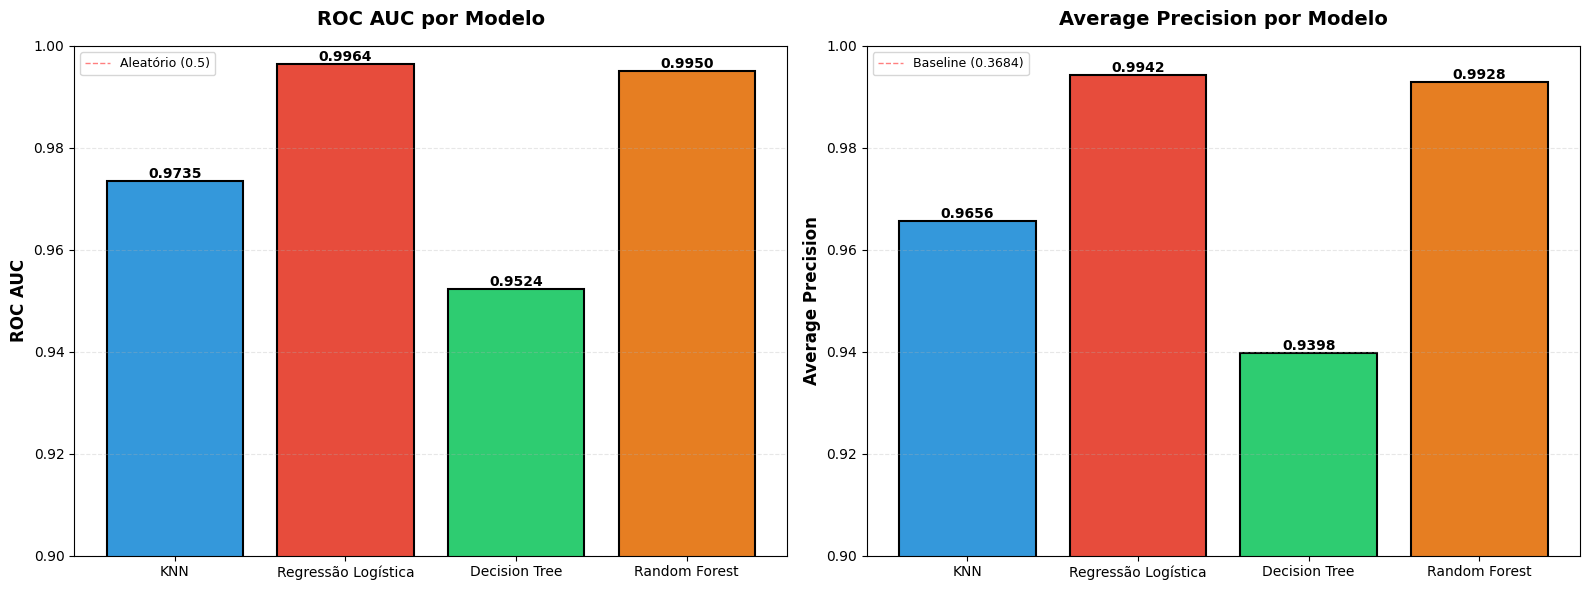

In [370]:
# Comparação Visual: ROC AUC vs Average Precision
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ROC AUC
models_list = list(roc_auc_scores.keys())
roc_auc_values = list(roc_auc_scores.values())
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22']

bars1 = ax1.bar(models_list, roc_auc_values, color=colors_roc, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('ROC AUC', fontweight='bold', fontsize=12)
ax1.set_title('ROC AUC por Modelo', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim(0.90, 1.0)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Aleatório (0.5)')
ax1.legend(fontsize=9)

for bar, value in zip(bars1, roc_auc_values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Average Precision
ap_values = list(ap_scores.values())
bars2 = ax2.bar(models_list, ap_values, color=colors_roc, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Average Precision', fontweight='bold', fontsize=12)
ax2.set_title('Average Precision por Modelo', fontweight='bold', fontsize=14, pad=15)
ax2.set_ylim(0.90, 1.0)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=baseline, color='red', linestyle='--', linewidth=1, alpha=0.5, 
           label=f'Baseline ({baseline:.4f})')
ax2.legend(fontsize=9)

for bar, value in zip(bars2, ap_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [371]:
# Resumo Comparativo: ROC AUC vs Average Precision
print("Comparação entre ROC AUC e Average Precision")

comparison_metrics = pd.DataFrame({
    'Modelo': list(roc_auc_scores.keys()),
    'ROC AUC': list(roc_auc_scores.values()),
    'Average Precision': list(ap_scores.values())
})

comparison_metrics = comparison_metrics.sort_values('ROC AUC', ascending=False)

print(comparison_metrics.to_string(index=False))

print("\nObservações:")
print("   - ROC AUC: Mede a capacidade geral de distinguir entre classes")
print("   - Average Precision: Mais relevante para dados desbalanceados")
print("   - Ambos os valores próximos de 1.0 indicam excelente performance")
print("   - Para diagnóstico médico, ambos são importantes:")
print("     * ROC AUC: Capacidade geral de classificação")
print("     * AP: Performance na classe minoritária (casos malignos)")


Comparação entre ROC AUC e Average Precision
             Modelo  ROC AUC  Average Precision
Regressão Logística 0.996362           0.994245
      Random Forest 0.995040           0.992817
                KNN 0.973545           0.965596
      Decision Tree 0.952381           0.939850

Observações:
   - ROC AUC: Mede a capacidade geral de distinguir entre classes
   - Average Precision: Mais relevante para dados desbalanceados
   - Ambos os valores próximos de 1.0 indicam excelente performance
   - Para diagnóstico médico, ambos são importantes:
     * ROC AUC: Capacidade geral de classificação
     * AP: Performance na classe minoritária (casos malignos)


In [372]:
# Resumo Comparativo Completo
print("Resumo comparativo completo\n")
print(f"{'KNN':<25} {knn_scores.mean():<12.4f} {knn_scores.std():<15.4f} {knn_scores.min():<10.4f} {knn_scores.max():<10.4f}")
print(f"{'Regressão Logística':<25} {lr_scores.mean():<12.4f} {lr_scores.std():<15.4f} {lr_scores.min():<10.4f} {lr_scores.max():<10.4f}")
print(f"{'Decision Tree':<25} {dt_scores.mean():<12.4f} {dt_scores.std():<15.4f} {dt_scores.min():<10.4f} {dt_scores.max():<10.4f}")
print(f"{'Random Forest':<25} {rf_scores.mean():<12.4f} {rf_scores.std():<15.4f} {rf_scores.min():<10.4f} {rf_scores.max():<10.4f}")

# Identificando o melhor modelo
model_scores = {
    'KNN': knn_scores.mean(),
    'Regressão Logística': lr_scores.mean(),
    'Decision Tree': dt_scores.mean(),
    'Random Forest': rf_scores.mean()
}

melhor_modelo = max(model_scores, key=model_scores.get)
melhor_score = model_scores[melhor_modelo]

print(f"\nMelhor modelo na validação cruzada: {melhor_modelo}")
print(f"Score médio: {melhor_score:.4f}")

Resumo comparativo completo

KNN                       0.9669       0.0206          0.9111     0.9783    
Regressão Logística       0.9736       0.0292          0.9111     1.0000    
Decision Tree             0.9274       0.0358          0.8667     1.0000    
Random Forest             0.9581       0.0232          0.9333     1.0000    

Melhor modelo na validação cruzada: Regressão Logística
Score médio: 0.9736


Acurácia no conjunto de teste

Modelo                    Acurácia    
Random Forest             0.9737      
Regressão Logística       0.9649      
KNN                       0.9561      
Decision Tree             0.9298      


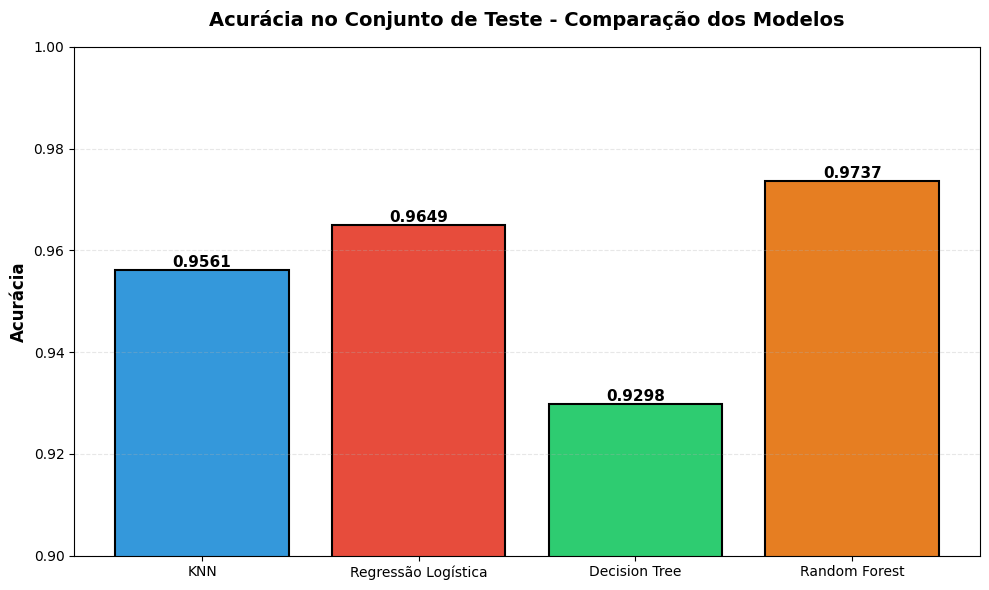

In [373]:
# Comparação de Acurácia no Conjunto de Teste
test_accuracies = {
    'KNN': accuracy_knn,
    'Regressão Logística': accuracy_lr,
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf
}

print("Acurácia no conjunto de teste")
print(f"\n{'Modelo':<25} {'Acurácia':<12}")
for model, acc in sorted(test_accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {acc:<12.4f}")

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
models_list = list(test_accuracies.keys())
accs_list = list(test_accuracies.values())
colors_test = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22']
bars = ax.bar(models_list, accs_list, color=colors_test, edgecolor='black', linewidth=1.5)

for bar, acc in zip(bars, accs_list):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{acc:.4f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Acurácia', fontsize=12, fontweight='bold')
ax.set_title('Acurácia no Conjunto de Teste - Comparação dos Modelos', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0.90, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
